# Task

- Implement and train Rectified Flow models both in:
    - Pixel-space, and
    - Latent-space (using your VAE encoder)
- Compare convergence speed, sample quality, and training stability between Diffusion (DDPM/DDIM) and Rectified Flow approaches

# Disclaimer

This notebook is both an implementation and a report with visualizations and justifications of approaches and results. There is no separate final report due to the inconvenience of reproducing the same structure in pdf.

Additional detailed explanations regarding parts that have been reused from previous works can be found in the relevant notebooks; they are not repeated here.

# Imports

In [1]:
import math
import time
from typing import Tuple, Dict, Optional, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Data Preparation

In [2]:
def get_mnist_loaders(
    dataset: str = "mnist",
    data_root: str = "./data",
    batch_size: int = 128,
    val_split: float = 0.1,
):
    if dataset == "mnist":
        DatasetClass = datasets.MNIST
    else:
        DatasetClass = datasets.FashionMNIST

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),  # (x - 0.5) / 0.5 -> [-1, 1]
    ])

    full_train = DatasetClass(root=data_root, train=True, download=True, transform=transform)
    test_ds = DatasetClass(root=data_root, train=False, download=True, transform=transform)

    n_total = len(full_train)
    n_val = int(n_total * val_split)
    n_train = n_total - n_val

    print(f"\n--- {dataset.upper()} DATASET ---")
    print(f"Total train images: {n_total}")
    print(f"  Train split:      {n_train}")
    print(f"  Validation split: {n_val}")
    print(f"Test set size:      {len(test_ds)}\n")

    train_ds, val_ds = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


def show_samples(loader, title: str):
    x, y = next(iter(loader))
    x, y = x[:4], y[:4]
    fig, axes = plt.subplots(1, 4, figsize=(8, 2))
    fig.suptitle(title)
    for i in range(4):
        axes[i].imshow(x[i].squeeze(0), cmap="gray")
        axes[i].set_title(f"label: {y[i].item()}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]



--- MNIST DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



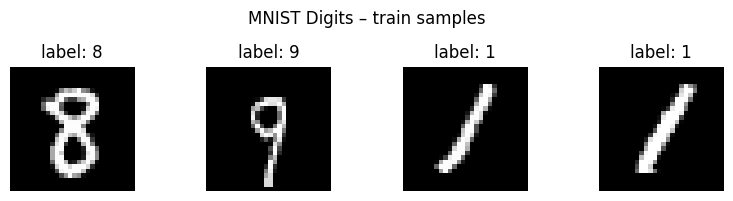

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 184kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.46MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.1MB/s]



--- FASHION DATASET ---
Total train images: 60000
  Train split:      54000
  Validation split: 6000
Test set size:      10000



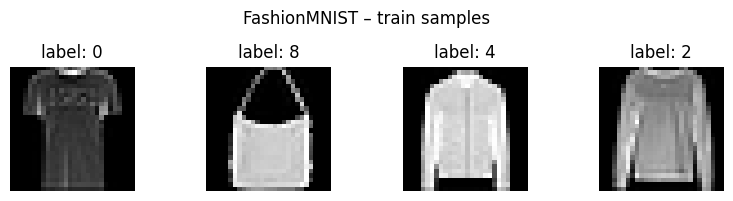

In [3]:
train_digits, val_digits, test_digits = get_mnist_loaders(dataset="mnist", batch_size=128)
show_samples(train_digits, "MNIST Digits – train samples")

train_fashion, val_fashion, test_fashion = get_mnist_loaders(dataset="fashion", batch_size=128)
show_samples(train_fashion, "FashionMNIST – train samples")

# General Helpers

## Visualization

In [4]:
def show_generated_grid(images, nrow=8, title="Generated Samples", figsize=(10, 4)):
    """Display a grid of generated images (expects images in [-1, 1])"""
    images = images.detach().cpu().clamp(-1, 1)
    images = (images + 1) / 2  # [-1,1] -> [0,1]

    n = min(len(images), nrow * (len(images) // nrow))
    fig, axes = plt.subplots(len(images) // nrow, nrow, figsize=figsize)
    if len(images) // nrow == 1:
        axes = axes[None, :]
    for i in range(n):
        r, c = i // nrow, i % nrow
        axes[r, c].imshow(images[i].squeeze(0), cmap="gray")
        axes[r, c].axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_losses(train_losses, val_losses, title="Training Loss"):
    """Plot training and validation loss curves"""
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def show_trajectory(trajectory, title="Flow Trajectory", nrow=10, figsize=(16, 3)):
    """
    Visualize intermediate states along the flow trajectory
    trajectory: list of tensors [(B,1,28,28), ...] at different time steps
    Shows the first sample from the batch across all time steps
    """
    n_steps = len(trajectory)
    step_indices = np.linspace(0, n_steps - 1, min(nrow, n_steps), dtype=int)

    fig, axes = plt.subplots(1, len(step_indices), figsize=figsize)
    for idx, step_i in enumerate(step_indices):
        img = trajectory[step_i][0].detach().cpu().clamp(-1, 1)
        img = (img + 1) / 2
        axes[idx].imshow(img.squeeze(0), cmap="gray")
        t_val = step_i / (n_steps - 1) if n_steps > 1 else 1.0
        axes[idx].set_title(f"t={t_val:.2f}", fontsize=9)
        axes[idx].axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

## Training

In [5]:
@torch.no_grad()
def compute_val_loss(model, val_loader, loss_fn, device):
    """Generic validation loss computation"""
    model.eval()
    total_loss, n = 0, 0
    for x, _ in val_loader:
        x = x.to(device)
        loss = loss_fn(model, x)
        total_loss += loss.item()
        n += 1
    return total_loss / n

# VAE

Reused from previous homework VAE compresses 28×28 images into a 32-dimensional latent vector.
This latent space is where we will run diffusion.

**Important** difference from standard LDM (Stable Diffusion): real LDMs use
[spatial latents](https://arxiv.org/pdf/2112.10752#page=3) (for example 4×32×32). This VAE produces a flat 32-dim vector, so we will use an MLP-based noise predictor instead of a U-Net. The core LDM concept idea to train diffusion in compressed space is identical.

## Architecture

In [6]:
class ConvVAEEncoder(nn.Module):
    """(B, 1, 28, 28) -> (mu, logvar) of shape (B, latent_dim)"""
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(64)
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        self.latent_dim = latent_dim

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)


class ConvVAEDecoder(nn.Module):
    """(B, latent_dim) -> (B, 1, 28, 28)"""
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv3 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(32)
        self.latent_dim = latent_dim

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 64, 7, 7)
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = torch.sigmoid(self.deconv3(x))
        return x


class ConvVAE(nn.Module):
    """Convolutional Variational Autoencoder"""
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.encoder = ConvVAEEncoder(latent_dim=latent_dim)
        self.decoder = ConvVAEDecoder(latent_dim=latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    @torch.no_grad()
    def encode(self, x):
        """Encode to latent mean (deterministic)"""
        mu, _ = self.encoder(x)
        return mu

    @torch.no_grad()
    def decode(self, z):
        """Decode latent vector to image"""
        return self.decoder(z)

## Training

VAE parameters: 416,193
Latent dim: 32 (compression: 784/32 = 24x)


VAE Epoch 1/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 61.3243  recon: 52.7931  kl: 8.5312  val: 35.8235


VAE Epoch 2/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 33.7268  recon: 21.6412  kl: 12.0856  val: 32.6719


...

  => loss: 28.1362  recon: 15.5615  kl: 12.5747  val: 28.1789


VAE Epoch 19/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 28.1080  recon: 15.5103  kl: 12.5977  val: 28.1547


VAE Epoch 20/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 28.0239  recon: 15.4435  kl: 12.5803  val: 28.1759


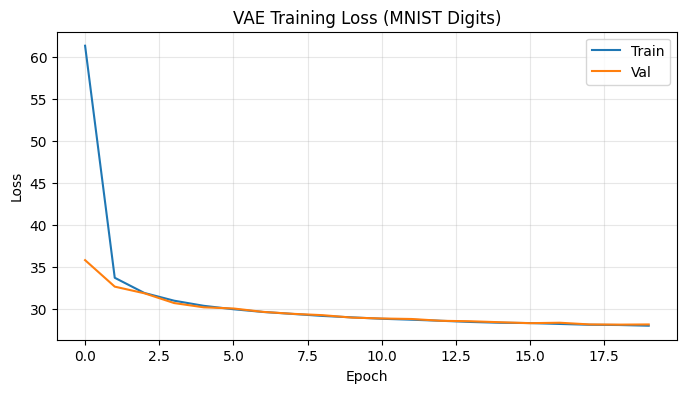

VAE parameters: 416,193
Latent dim: 32 (compression: 784/32 = 24x)


VAE Epoch 1/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 37.4062  recon: 28.3681  kl: 9.0381  val: 29.4741


VAE Epoch 2/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 28.3004  recon: 19.9452  kl: 8.3552  val: 27.9416


...

  => loss: 24.3520  recon: 16.0394  kl: 8.3126  val: 24.4410


VAE Epoch 19/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 24.2849  recon: 15.9906  kl: 8.2943  val: 24.3151


VAE Epoch 20/20:   0%|          | 0/422 [00:00<?, ?it/s]

  => loss: 24.2459  recon: 15.9419  kl: 8.3040  val: 24.5060


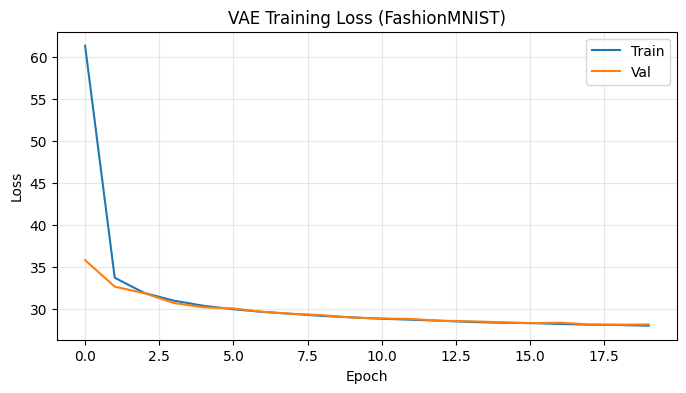

In [7]:
def vae_loss_fn(x_recon, x_target, mu, logvar, beta: float = 1.0):
    recon_loss = F.mse_loss(x_recon, x_target, reduction='sum') / x_target.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x_target.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


def train_vae(
    model: ConvVAE,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 20,
    lr: float = 1e-3,
    beta: float = 1.0,
    device: str = "cuda",
) -> Tuple[ConvVAE, dict]:
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_recon": [], "train_kl": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, epoch_recon, epoch_kl, n = 0, 0, 0, 0
        pbar = tqdm(train_loader, desc=f"VAE Epoch {epoch+1}/{epochs}")
        for x, _ in pbar:
            x_01 = (x.to(device) + 1) / 2
            x_recon, mu, logvar = model(x_01)
            loss, recon, kl = vae_loss_fn(x_recon, x_01, mu, logvar, beta)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
            n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_loss_sum, val_n = 0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x_01 = (x.to(device) + 1) / 2
                x_recon, mu, logvar = model(x_01)
                loss, _, _ = vae_loss_fn(x_recon, x_01, mu, logvar, beta)
                val_loss_sum += loss.item()
                val_n += 1

        history["train_loss"].append(epoch_loss / n)
        history["val_loss"].append(val_loss_sum / val_n)
        history["train_recon"].append(epoch_recon / n)
        history["train_kl"].append(epoch_kl / n)
        print(f"  => loss: {epoch_loss/n:.4f}  recon: {epoch_recon/n:.4f}  "
              f"kl: {epoch_kl/n:.4f}  val: {val_loss_sum/val_n:.4f}")

    return model, history


VAE_LATENT_DIM = 32
VAE_EPOCHS = 20

vae = ConvVAE(latent_dim=VAE_LATENT_DIM).to(device)
print(f"VAE parameters: {sum(p.numel() for p in vae.parameters()):,}")
print(f"Latent dim: {VAE_LATENT_DIM} (compression: {28*28}/{VAE_LATENT_DIM} = {28*28/VAE_LATENT_DIM:.0f}x)")

vae, vae_history = train_vae(
    vae, train_digits, val_digits,
    epochs=VAE_EPOCHS, lr=1e-3, device=device,
)
plot_losses(vae_history["train_loss"], vae_history["val_loss"], "VAE Training Loss (MNIST Digits)")


vae_fashion = ConvVAE(latent_dim=VAE_LATENT_DIM).to(device)
print(f"VAE parameters: {sum(p.numel() for p in vae.parameters()):,}")
print(f"Latent dim: {VAE_LATENT_DIM} (compression: {28*28}/{VAE_LATENT_DIM} = {28*28/VAE_LATENT_DIM:.0f}x)")

vae_fashion, vae_fashion_history = train_vae(
    vae_fashion, train_fashion, val_fashion,
    epochs=VAE_EPOCHS, lr=1e-3, device=device,
)
plot_losses(vae_history["train_loss"], vae_history["val_loss"], "VAE Training Loss (FashionMNIST)")

### Quality Check

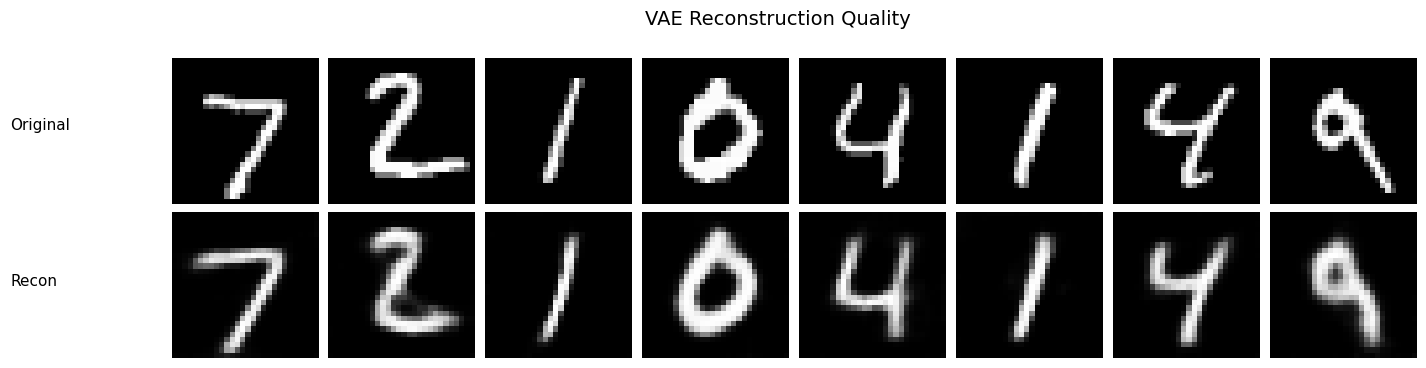

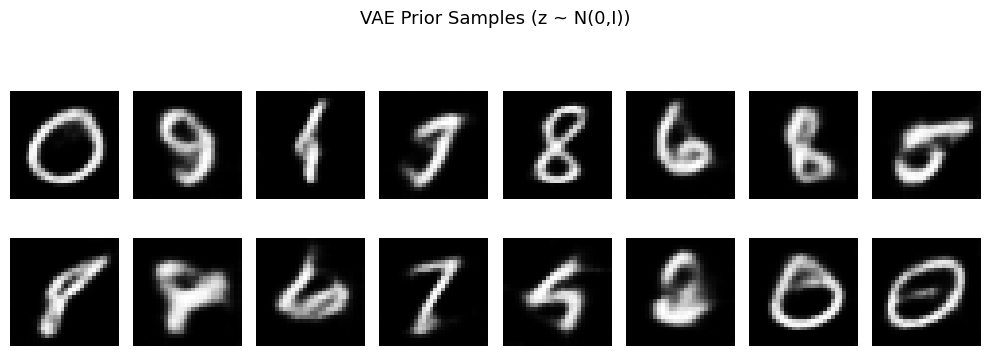

In [8]:
vae.eval()
x_test, _ = next(iter(test_digits))
x_test_01 = (x_test[:8].to(device) + 1) / 2

with torch.no_grad():
    x_recon, _, _ = vae(x_test_01)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_test_01[i].detach().cpu().squeeze(0), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_recon[i].detach().cpu().squeeze(0), cmap="gray")
    axes[1, i].axis("off")
fig.text(0.02, 0.69, "Original", ha="left", va="center", fontsize=11)
fig.text(0.02, 0.30, "Recon", ha="left", va="center", fontsize=11)
fig.suptitle("VAE Reconstruction Quality", fontsize=14)
plt.subplots_adjust(left=0.12, top=0.86, wspace=0.05, hspace=0.05)
plt.show()

with torch.no_grad():
    z_random = torch.randn(16, VAE_LATENT_DIM, device=device)
    prior_samples = vae.decode(z_random)
show_generated_grid(prior_samples * 2 - 1, nrow=8, title="VAE Prior Samples (z ~ N(0,I))", figsize=(10, 4))

# Rectified Flow

Both [DDPM](https://arxiv.org/pdf/2006.11239) and [rectified flow](https://arxiv.org/pdf/2209.03003) solve the same problem of learning a mapping from a simple distribution $\pi_0$ (Gaussian noise) to a complex data distribution $\pi_1$ (real images). The difference is *how* they construct this mapping. DDPM gradually destroys data with noise over $T=1000$ steps, then learns to reverse this process step by step. This results in curved, complex trajectories through the space and requires many neural network evaluations to generate a single sample. Rectified flow learns an ODE onto the velocity fields whose trajectories are as straight as possible. A perfectly straight trajectory from noise to data can be traversed in a single step.

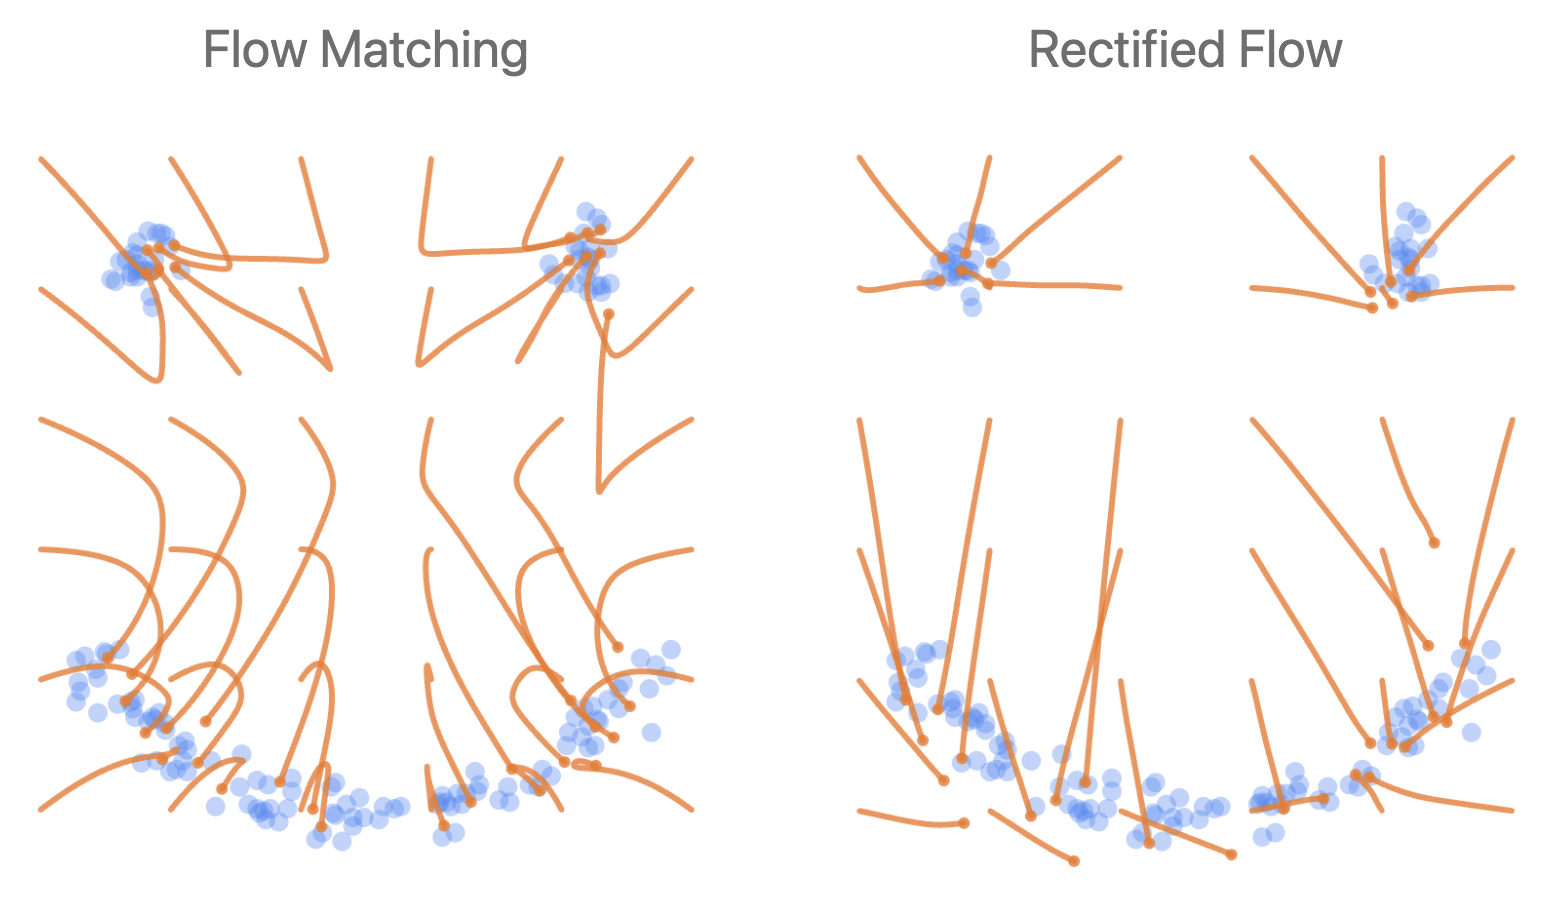

Source: [A Visual Introduction to Rectified Flows](https://alechelbling.com/blog/rectified-flow/) by [Alec Helbling](https://alechelbling.com/)

The key idea starts with a simple observation: gven a noise sample $X_0 \sim \pi_0 = N(0, I)$ and a data sample $X_1 \sim \pi_1$, the **linear interpolation** between them is:

$$X_t = t \cdot X_1 + (1 - t) \cdot X_0, \quad t \in [0, 1]$$

This interpolation trivially connects $\pi_0$ to $\pi_1$, but it order to compute $X_t$, we need to know $X_1$ (the final image), which is exactly what we are trying to generate. Rectified flow fixes this by training a neural network $v_\theta(z, t)$ to predict the velocity $(X_1 - X_0)$ (the direction of the straight line) given only the current position $X_t$ and the current time $t$. This "causalizes" the interpolation into a proper ODE:

$$dZ_t = v_\theta(Z_t, t) \, dt$$

And now we can start from $Z_0 \sim \pi_0$ and integrate forward without knowing where you will end up.

**Training Objective**

The loss function is a straightforward least squares regression:

$$L(\theta) = \int_0^1 \mathbb{E}\left[\left\|(X_1 - X_0) - v_\theta(X_t, t)\right\|^2\right] dt, \quad \text{where } X_t = t X_1 + (1-t) X_0$$

In practice, we sample $t \sim \text{Uniform}(0, 1)$ and compute stochastic gradients:

$$L_{\text{batch}} = \mathbb{E}_{t, X_0, X_1}\left[\left\|(X_1 - X_0) - v_\theta(tX_1 + (1-t)X_0,\; t)\right\|^2\right]$$

That is literally the entire training procedure. Very simple in comparison to the DDPM, where we need a noise schedule $\{\beta_t\}_{t=1}^T$, cumulative products $\bar{\alpha}_t$, and the reparameterized noise prediction loss.

When the loss is minimized exactly, the optimal velocity field is:

$$v^*(x, t) = \mathbb{E}[X_1 - X_0 \mid X_t = x]$$

This is the conditional expectation of the line direction, averaged over all pairs $(X_0, X_1)$ whose interpolation passes through point $x$ at time $t$. The neural network learns to approximate this conditional average.

**Key theoretical result** ([Theorem 3.3](https://arxiv.org/pdf/2209.03003#page=13) from the paper): the flow $Z_t$ driven by this velocity field preserves marginal distributions — that is, $\text{Law}(Z_t) = \text{Law}(X_t)$ for all $t \in [0, 1]$. In particular, $Z_1 \sim \pi_1$, so the flow does correctly transport noise to data.

**Why does rectified flow produce good couplings?**

Due to the fundamental property of ODEs, trajectories of a well-defined ODE [cannot cross each other](https://arxiv.org/pdf/2209.03003#page=5). If two paths met at the same point at the same time, the ODE would have non-unique solutions, violating the existence-uniqueness theorem.

The linear interpolation paths $X_t = tX_1 + (1-t)X_0$ can and do cross (imagine two pairs $(X_0, X_1)$ and $(X_0', X_1')$ whose connecting lines intersect). The rectified flow "rewires" these paths at intersection points to avoid crossing, while preserving the same marginal densities at every time $t$.

This rewiring provably reduces transport costs:

$$\mathbb{E}[c(Z_1 - Z_0)] \leq \mathbb{E}[c(X_1 - X_0)] \quad \text{for any convex } c$$

**Reflow Procedure**

The first rectified flow (1-rectified flow) already uncrosses paths, but they are not yet perfectly straight. The **reflow** procedure iteratively straightens them:

1. Train the 1-rectified flow from data pairs $(X_0, X_1) \sim \pi_0 \times \pi_1$
2. Generate new pairs $(Z_0^1, Z_1^1)$ by simulating the 1-rectified flow
3. Train the 2-rectified flow on pairs $(Z_0^1, Z_1^1)$
4. Repeat as desired

Each step makes paths straighter. The straightness measure $S(\mathbf{Z}) = \int_0^1 \mathbb{E}[\|(Z_1 - Z_0) - \dot{Z}_t\|^2] \, dt$ converges to zero at rate $O(1/K)$ after $K$ reflow steps.

We care about straightness, because a flow with perfectly straight paths satisfies $Z_1 = Z_0 + v(Z_0, 0)$. And that is a single Euler step.


**Comparison with DDPM/DDIM**

| Aspect | DDPM | DDIM | Rectified Flow |
|--------|------|------|----------------|
| **Process type** | SDE (stochastic) | ODE (deterministic) | ODE (deterministic) |
| **Trajectory shape** | Random walks | Curved paths | Nearly straight paths |
| **Training target** | Predict noise $\epsilon$ | Same model as DDPM | Predict velocity $(X_1 - X_0)$ |
| **Noise schedule** | Required ($\beta_t$, $\bar\alpha_t$) | Inherited from DDPM | None |
| **Typical NFE** | 1000 | 50–100 | 1–10 (after reflow) |
| **Training loss** | $\|\epsilon - \epsilon_\theta(x_t, t)\|^2$ | Same as DDPM | $\|(X_1-X_0) - v_\theta(X_t,t)\|^2$ |
| **Theory** | Score matching + SDE reversal | Probability flow ODE | Linear interpolation + causalization |

The paper shows that DDIM is actually [a special case of the "nonlinear rectified flow"](https://arxiv.org/pdf/2209.03003#page=9) framework with a specific curved interpolation $X_t = \alpha_t X_1 + \beta_t \epsilon$ where $\beta_t = \sqrt{1 - \alpha_t^2}$. The curved paths of DDIM cannot be straightened by reflowing. Rectified flow uses the canonical $\beta_t = 1 - t$, which induces straight paths and enables the reflow trick.

## Pixel Space

The same U-Net is reused from the DDPM lab. The architecture is identical, only the training procedure changes. In DDPM, this network predicted noise $\epsilon$; here it predicts the velocity field $v(X_t, t)$.

**Note** on time conditioning: in DDPM, the integer timestep $t \in \{0, ..., 999\}$ was passed to sinusoidal embeddings. For rectified flow, $t \in [0, 1]$ is continuous. We need to scale it to match the embedding range, so we pass $t \times 1000$ to the same sinusoidal embedding layer. This way the embedding sees values in $[0, 1000]$ just like before, and the pretrained-style architecture works out of the box.

In [9]:
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal positional embedding for the timestep"""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    """Residual block with time conditioning via additive bias"""
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, dropout: float = 0.1):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
        )
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(), nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
        )
        self.skip_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.skip_conv(x)


class SelfAttention(nn.Module):
    """Single-head self-attention over spatial dims (at 7x7 bottleneck)"""
    def __init__(self, channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = (q.transpose(-1, -2) @ k) * self.scale
        attn = attn.softmax(dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(B, C, H, W)
        return x + self.proj(out)


class UNet(nn.Module):
    """U-Net velocity prediction network for MNIST (28x28 grayscale)"""
    def __init__(self, in_ch: int = 1, base_ch: int = 64, time_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # encoder
        self.conv_in = nn.Conv2d(in_ch, ch1, 3, padding=1)
        self.down1_res1 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_res2 = ResBlock(ch1, ch1, time_dim, dropout)
        self.down1_pool = nn.Conv2d(ch1, ch1, 3, stride=2, padding=1)
        self.down2_res1 = ResBlock(ch1, ch2, time_dim, dropout)
        self.down2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.down2_pool = nn.Conv2d(ch2, ch2, 3, stride=2, padding=1)

        # bottleneck
        self.mid_res1 = ResBlock(ch2, ch3, time_dim, dropout)
        self.mid_attn = SelfAttention(ch3)
        self.mid_res2 = ResBlock(ch3, ch3, time_dim, dropout)

        # decoder
        self.up2_upsample = nn.ConvTranspose2d(ch3, ch3, 4, stride=2, padding=1)
        self.up2_res1 = ResBlock(ch3 + ch2, ch2, time_dim, dropout)
        self.up2_res2 = ResBlock(ch2, ch2, time_dim, dropout)
        self.up1_upsample = nn.ConvTranspose2d(ch2, ch2, 4, stride=2, padding=1)
        self.up1_res1 = ResBlock(ch2 + ch1, ch1, time_dim, dropout)
        self.up1_res2 = ResBlock(ch1, ch1, time_dim, dropout)

        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, ch1), nn.SiLU(),
            nn.Conv2d(ch1, in_ch, 3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)

        h = self.conv_in(x)
        h1 = self.down1_res2(self.down1_res1(h, t_emb), t_emb)
        h = self.down1_pool(h1)
        h2 = self.down2_res2(self.down2_res1(h, t_emb), t_emb)
        h = self.down2_pool(h2)

        h = self.mid_res1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_res2(h, t_emb)

        h = self.up2_upsample(h)
        h = torch.cat([h, h2], dim=1)
        h = self.up2_res2(self.up2_res1(h, t_emb), t_emb)

        h = self.up1_upsample(h)
        h = torch.cat([h, h1], dim=1)
        h = self.up1_res2(self.up1_res1(h, t_emb), t_emb)

        return self.conv_out(h)

In [10]:
# sanity check
model_test = UNet().to(device)
n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"U-Net parameters: {n_params:,}")

with torch.no_grad():
    dummy_x = torch.randn(2, 1, 28, 28, device=device)
    dummy_t = torch.rand(2, device=device) * 1000 # continuous t scaled to [0, 1000]
    out = model_test(dummy_x, dummy_t)
    print(f"Input:  {dummy_x.shape}")
    print(f"Output: {out.shape}")
    assert out.shape == dummy_x.shape
    print("U-Net forward OK")
del model_test

U-Net parameters: 6,166,081
Input:  torch.Size([2, 1, 28, 28])
Output: torch.Size([2, 1, 28, 28])
U-Net forward OK


### Pixel Rectified Flow

Algorithm (from the paper):

1. Sample $X_0 \sim N(0, I)$ and $X_1 \sim \pi_1$ (real images) independently
2. Sample $t \sim \text{Uniform}(0, 1)$
3. Compute interpolation: $X_t = t \cdot X_1 + (1-t) \cdot X_0$
4. Compute target velocity: $\text{target} = X_1 - X_0$
5. Predict velocity: $\hat{v} = v_\theta(X_t, t)$
6. Loss: $L = \|\hat{v} - \text{target}\|^2$

In [11]:
class RectifiedFlowPixel:
    """
    Rectified Flow in pixel space

    The model v_theta(x_t, t) predicts the velocity field of an ODE
    that transports Gaussian noise (pi_0) to data (pi_1) along straight paths.
    """

    def __init__(self, model: UNet, device: str = "cuda"):
        self.model = model.to(device)
        self.device = device

    def compute_loss(self, x1: torch.Tensor) -> torch.Tensor:
        """Compute the rectified flow training loss for a batch of data images x1"""
        B = x1.shape[0]

        # sample noise (source distribution)
        x0 = torch.randn_like(x1)

        # sample time uniformly in [0, 1]
        t = torch.rand(B, device=self.device)

        # linear interpolation
        x_t = t[:, None, None, None] * x1 + (1 - t[:, None, None, None]) * x0

        # target
        target = x1 - x0

        # predict velocity (scale t for sinusoidal embedding compatibility)
        v_pred = self.model(x_t, t * 1000)

        loss = F.mse_loss(v_pred, target) # MSE
        return loss

    @torch.no_grad()
    def sample_euler(
        self,
        n_samples: int,
        n_steps: int = 10,
        shape: Tuple = (1, 28, 28),
        return_trajectory: bool = False,
    ) -> torch.Tensor:
        """Generate samples by solving the ODE with the Euler method"""
        self.model.eval()
        dt = 1.0 / n_steps

        # start from pure noise
        z = torch.randn(n_samples, *shape, device=self.device)
        trajectory = [z.cpu()] if return_trajectory else None

        for i in range(n_steps):
            t = torch.ones(n_samples, device=self.device) * (i * dt)
            v = self.model(z, t * 1000)
            z = z + v * dt

            if return_trajectory:
                trajectory.append(z.cpu())

        if return_trajectory:
            return z, trajectory
        return z

    @torch.no_grad()
    def sample_rk4(
        self,
        n_samples: int,
        n_steps: int = 10,
        shape: Tuple = (1, 28, 28),
    ) -> torch.Tensor:
        """
        Generate samples using the classical RK4 ODE solver
        More accurate than Euler for the same number of steps,
        but requires 4 model evaluations per step
        """
        self.model.eval()
        dt = 1.0 / n_steps
        z = torch.randn(n_samples, *shape, device=self.device)

        for i in range(n_steps):
            t_i = i * dt
            t_tensor = torch.ones(n_samples, device=self.device)

            k1 = self.model(z, t_tensor * t_i * 1000)
            k2 = self.model(z + 0.5 * dt * k1, t_tensor * (t_i + 0.5 * dt) * 1000)
            k3 = self.model(z + 0.5 * dt * k2, t_tensor * (t_i + 0.5 * dt) * 1000)
            k4 = self.model(z + dt * k3, t_tensor * (t_i + dt) * 1000)

            z = z + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

        return z

In [12]:
def train_rectified_flow_pixel(
    rf: RectifiedFlowPixel,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 30,
    lr: float = 2e-4,
    device: str = "cuda",
) -> dict:
    """Train the pixel-space rectified flow model"""
    optimizer = torch.optim.Adam(rf.model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        rf.model.train()
        epoch_loss, n = 0, 0

        pbar = tqdm(train_loader, desc=f"RF-Pixel Epoch {epoch+1}/{epochs}")
        for x, _ in pbar:
            x1 = x.to(device) # data images in [-1, 1]
            loss = rf.compute_loss(x1)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        # validation
        rf.model.eval()
        val_loss_sum, val_n = 0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x1 = x.to(device)
                loss = rf.compute_loss(x1)
                val_loss_sum += loss.item()
                val_n += 1

        avg_train = epoch_loss / n
        avg_val = val_loss_sum / val_n
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        print(f"  => train_loss: {avg_train:.4f}  val_loss: {avg_val:.4f}")

    return history

### MNIST Digits

#### Training

Rectified Flow (pixel) parameters: 6,166,081


RF-Pixel Epoch 1/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.3232  val_loss: 0.2226


RF-Pixel Epoch 2/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.2187  val_loss: 0.1996


...

  => train_loss: 0.1709  val_loss: 0.1682


RF-Pixel Epoch 29/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.1706  val_loss: 0.1695


RF-Pixel Epoch 30/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.1719  val_loss: 0.1687


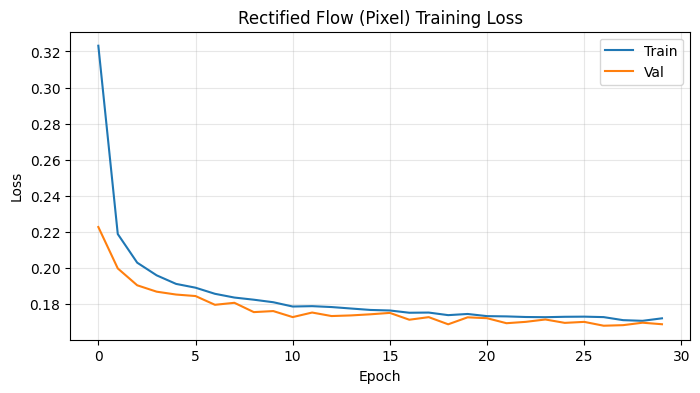

In [13]:
RF_PIXEL_EPOCHS = 30

rf_pixel_model = UNet(in_ch=1, base_ch=64, time_dim=256, dropout=0.1).to(device)
rf_pixel = RectifiedFlowPixel(rf_pixel_model, device=device)

print(f"Rectified Flow (pixel) parameters: {sum(p.numel() for p in rf_pixel_model.parameters()):,}")

rf_pixel_history = train_rectified_flow_pixel(
    rf_pixel, train_digits, val_digits,
    epochs=RF_PIXEL_EPOCHS, lr=2e-4, device=device,
)
plot_losses(rf_pixel_history["train_loss"], rf_pixel_history["val_loss"],
            "Rectified Flow (Pixel) Training Loss")

#### Sampling

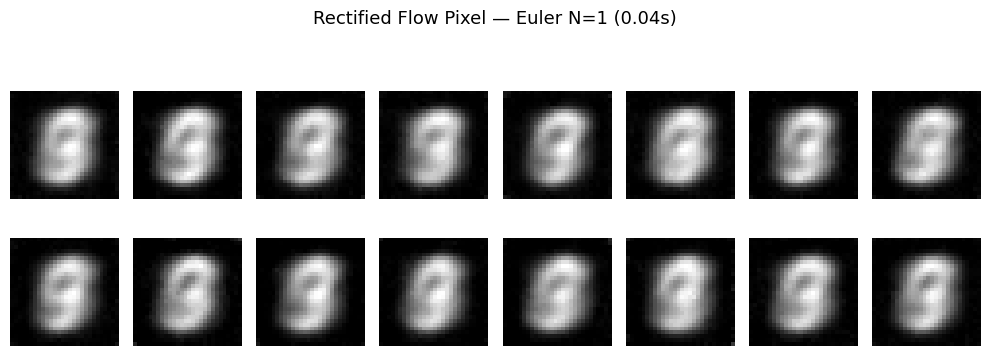

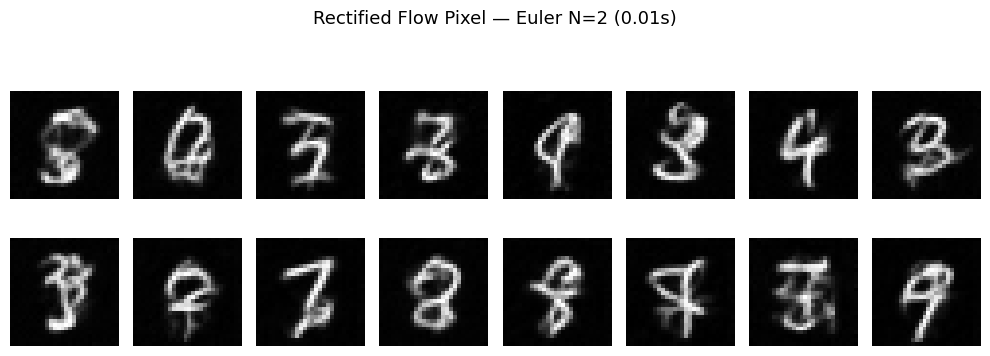

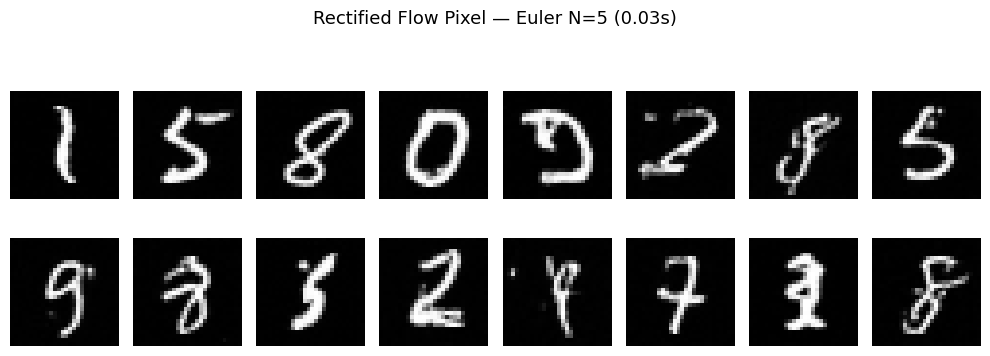

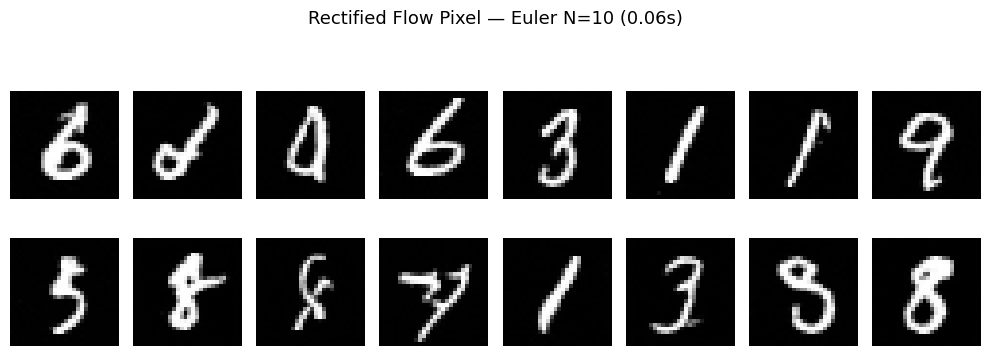

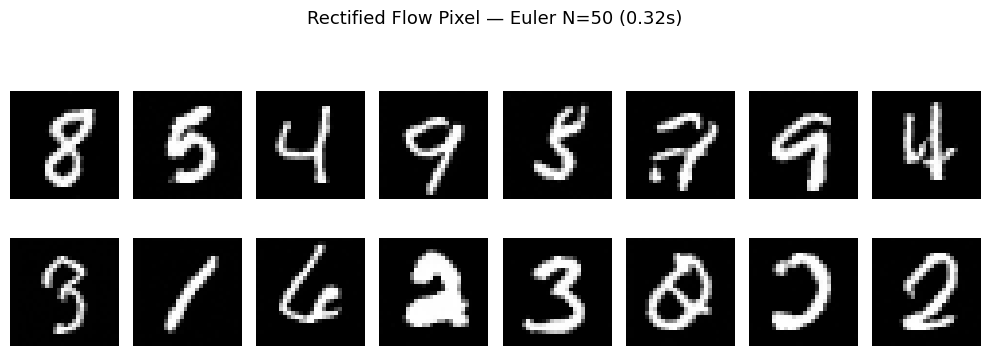

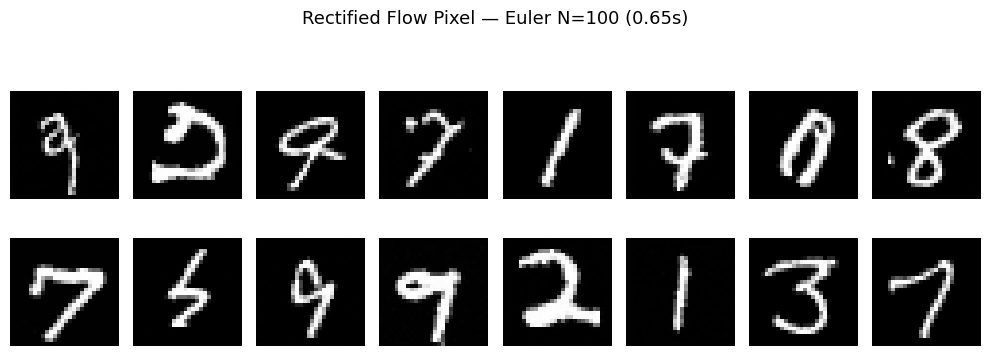

In [14]:
rf_pixel.model.eval()

for n_steps in [1, 2, 5, 10, 50, 100]:
    t0 = time.time()
    samples = rf_pixel.sample_euler(n_samples=16, n_steps=n_steps)
    elapsed = time.time() - t0
    show_generated_grid(
        samples, nrow=8,
        title=f"Rectified Flow Pixel — Euler N={n_steps} ({elapsed:.2f}s)",
        figsize=(10, 4),
    )

#### Trajectories

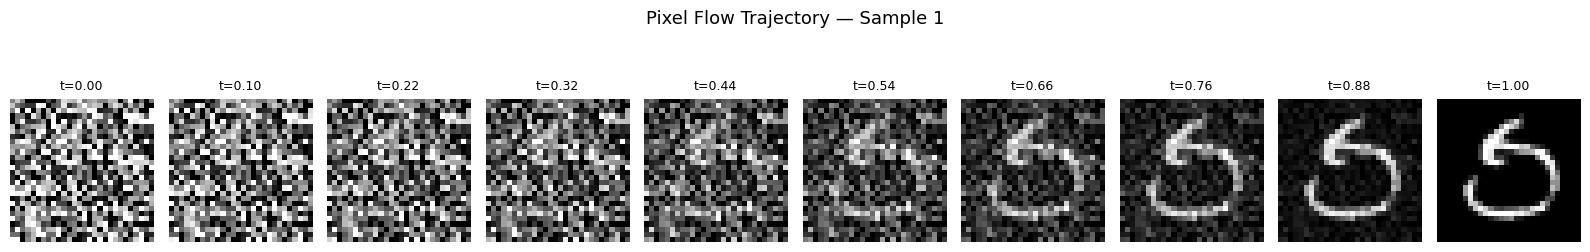

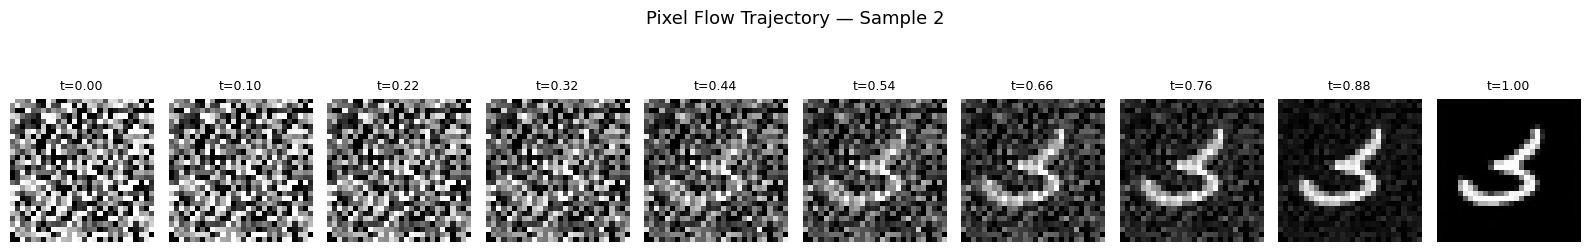

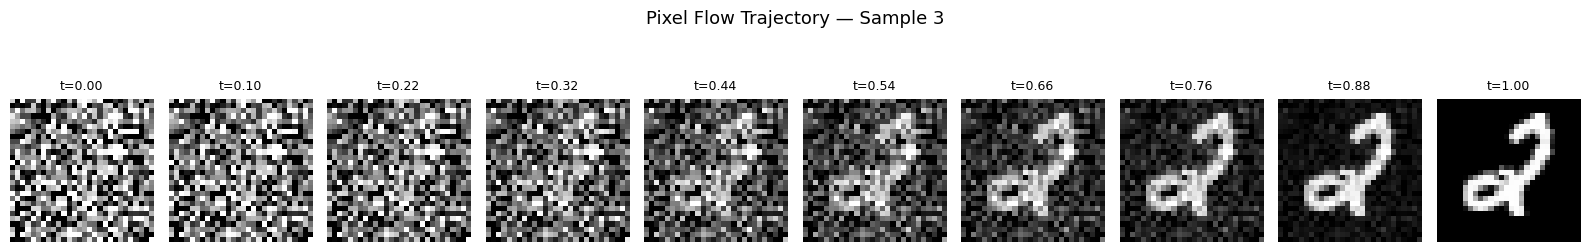

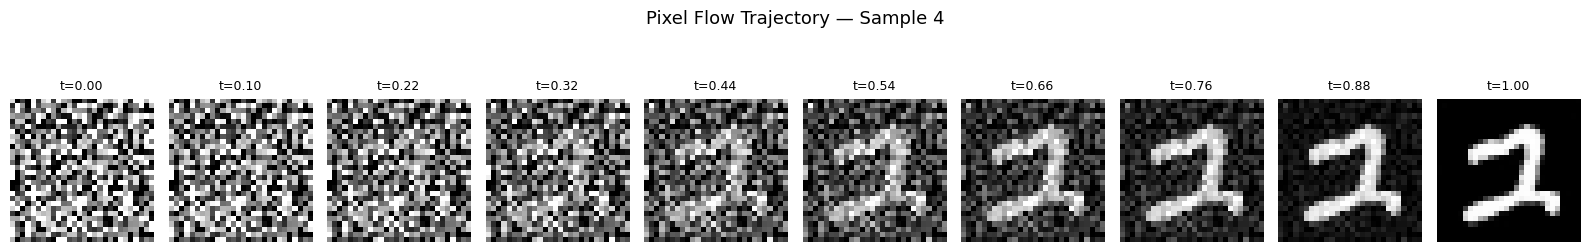

In [15]:
samples, trajectory = rf_pixel.sample_euler(
    n_samples=4, n_steps=50, return_trajectory=True
)
for i in range(4):
    traj_i = [t[i:i+1] for t in trajectory]
    show_trajectory(traj_i, title=f"Pixel Flow Trajectory — Sample {i+1}", nrow=10)

#### RK4 vs Euler Comparison

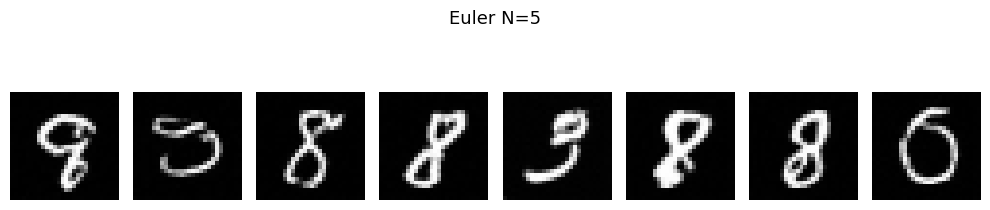

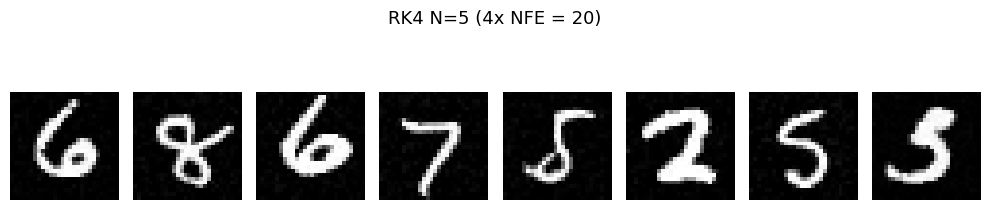

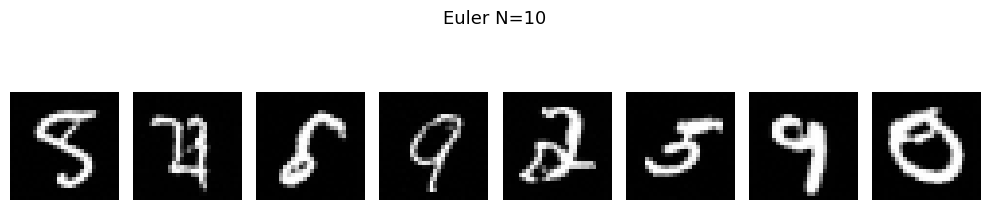

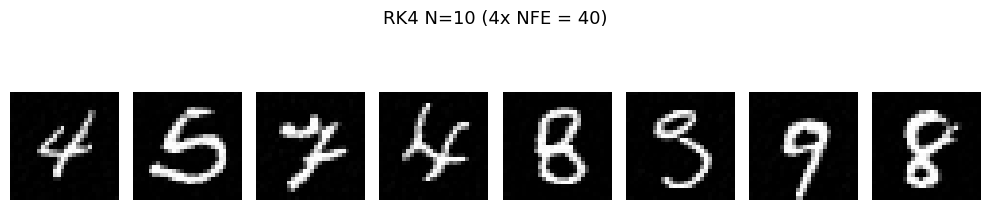

In [16]:
for n_steps in [5, 10]:
    samples_euler = rf_pixel.sample_euler(n_samples=8, n_steps=n_steps)
    samples_rk4 = rf_pixel.sample_rk4(n_samples=8, n_steps=n_steps)

    show_generated_grid(samples_euler, nrow=8,
                        title=f"Euler N={n_steps}", figsize=(10, 2.5))
    show_generated_grid(samples_rk4, nrow=8,
                        title=f"RK4 N={n_steps} (4x NFE = {n_steps*4})", figsize=(10, 2.5))

### FashionMNIST

#### Training

RF-Pixel Epoch 1/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.4030  val_loss: 0.2931


RF-Pixel Epoch 2/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.2908  val_loss: 0.2704


RF-Pixel Epoch 3/30:   0%|          | 0/422 [00:00<?, ?it/s]

...

  => train_loss: 0.2254  val_loss: 0.2243


RF-Pixel Epoch 29/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.2248  val_loss: 0.2235


RF-Pixel Epoch 30/30:   0%|          | 0/422 [00:00<?, ?it/s]

  => train_loss: 0.2242  val_loss: 0.2256


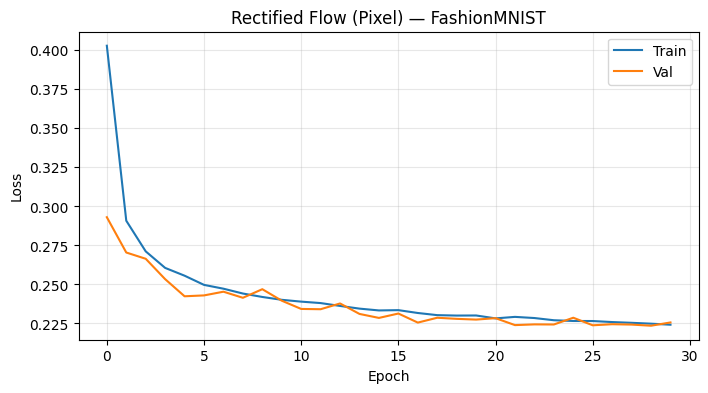

In [17]:
rf_pixel_fashion_model = UNet(in_ch=1, base_ch=64, time_dim=256, dropout=0.1).to(device)
rf_pixel_fashion = RectifiedFlowPixel(rf_pixel_fashion_model, device=device)

rf_pixel_fashion_history = train_rectified_flow_pixel(
    rf_pixel_fashion, train_fashion, val_fashion,
    epochs=RF_PIXEL_EPOCHS, lr=2e-4, device=device,
)
plot_losses(rf_pixel_fashion_history["train_loss"], rf_pixel_fashion_history["val_loss"],
            "Rectified Flow (Pixel) — FashionMNIST")

#### Sampling

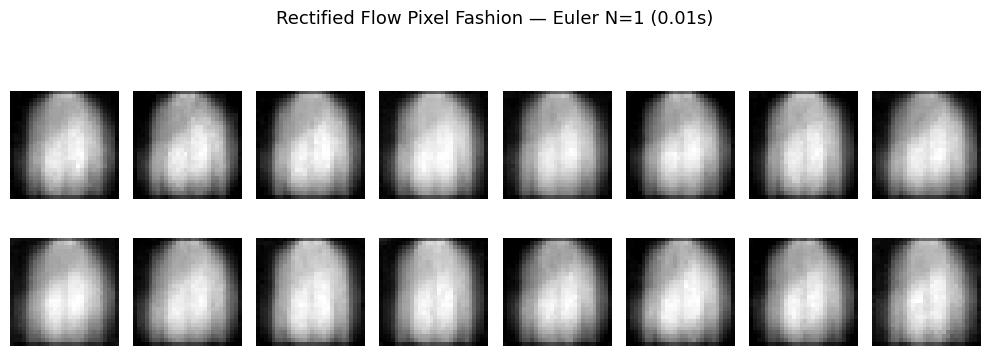

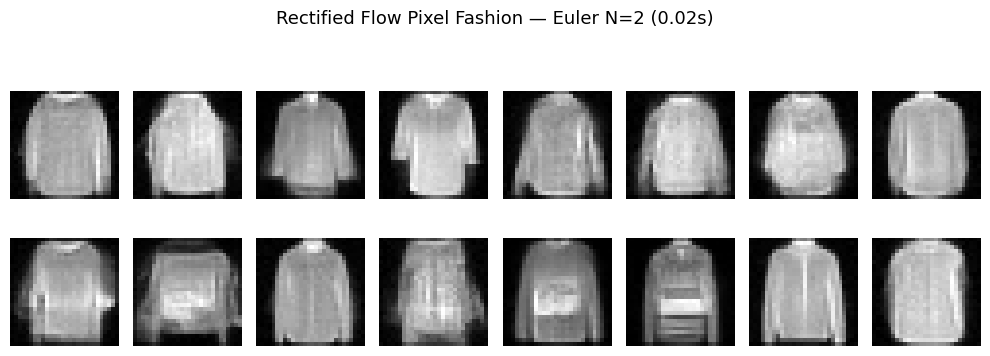

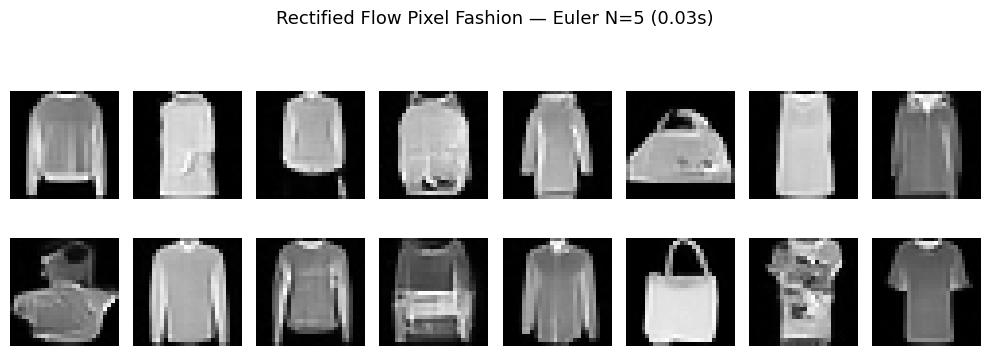

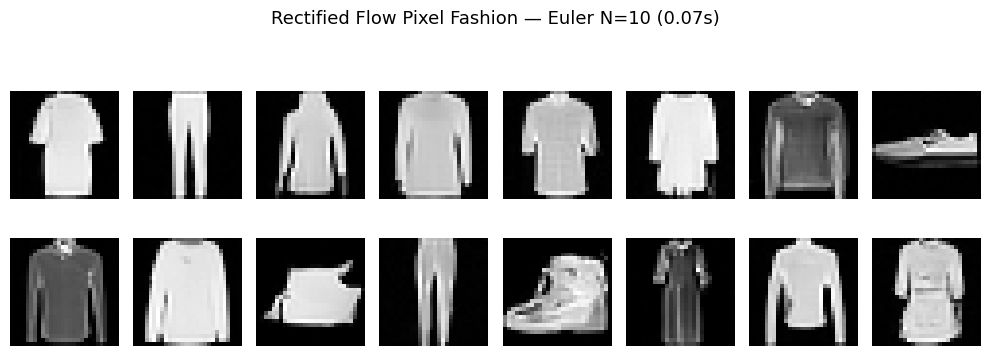

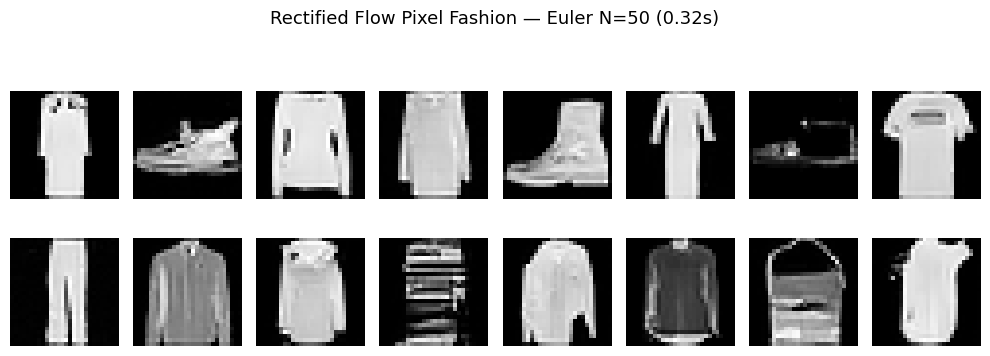

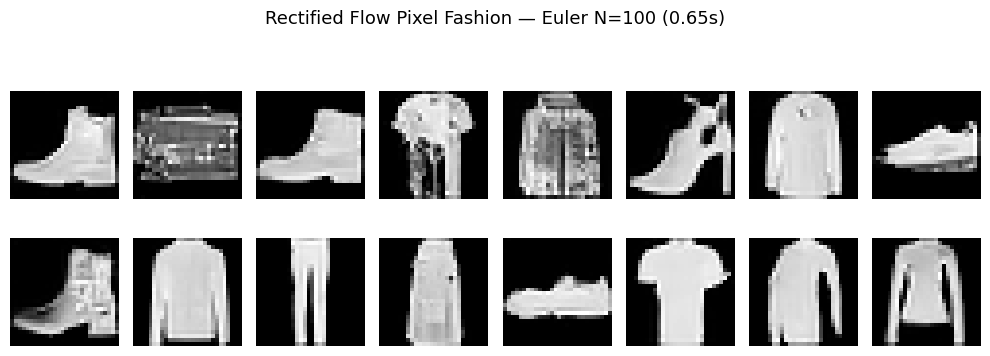

In [18]:
rf_pixel_fashion.model.eval()

for n_steps in [1, 2, 5, 10, 50, 100]:
    t0 = time.time()
    samples = rf_pixel_fashion.sample_euler(n_samples=16, n_steps=n_steps)
    elapsed = time.time() - t0
    show_generated_grid(
        samples, nrow=8,
        title=f"Rectified Flow Pixel Fashion — Euler N={n_steps} ({elapsed:.2f}s)",
        figsize=(10, 4),
    )

#### Trajectories

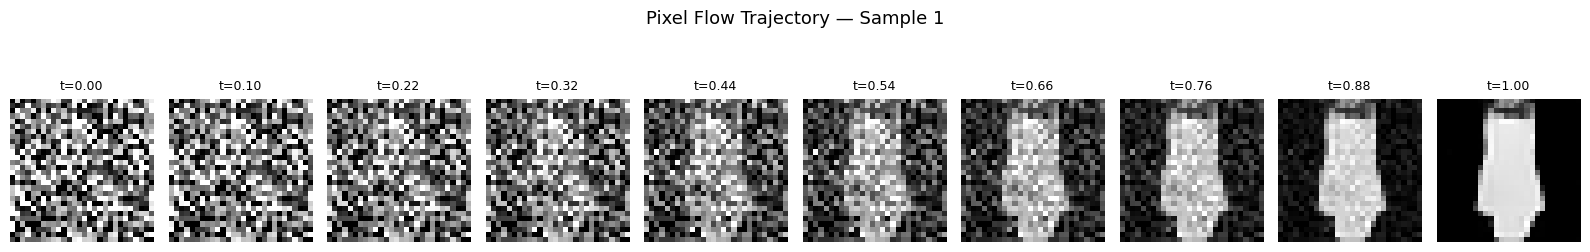

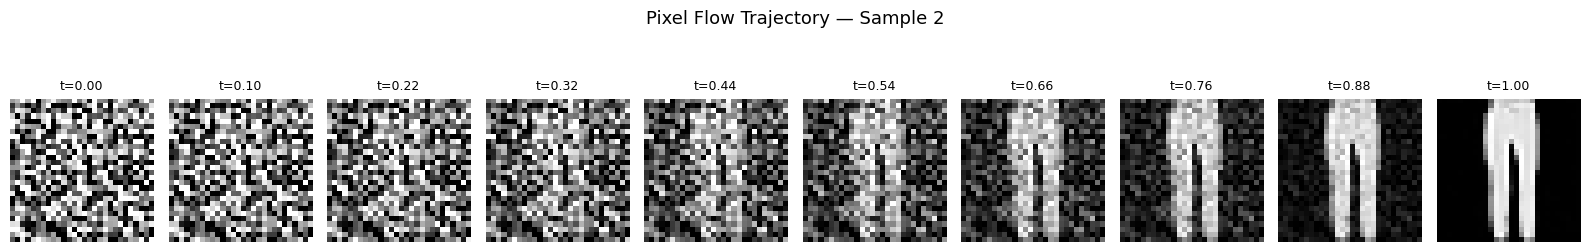

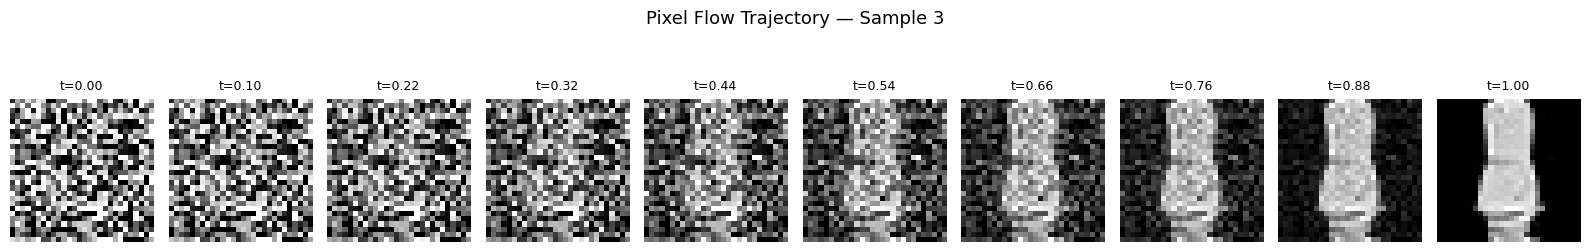

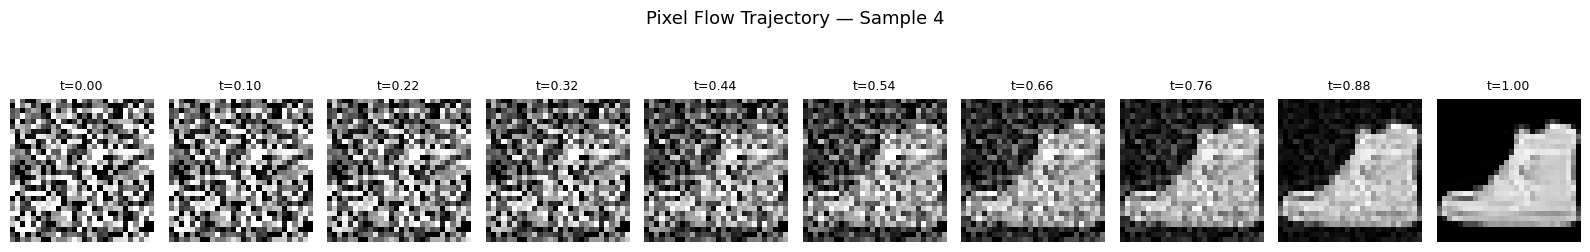

In [19]:
samples, trajectory = rf_pixel_fashion.sample_euler(
    n_samples=4, n_steps=50, return_trajectory=True
)
for i in range(4):
    traj_i = [t[i:i+1] for t in trajectory]
    show_trajectory(traj_i, title=f"Pixel Flow Trajectory — Sample {i+1}", nrow=10)

#### RK4 vs Euler Comparison

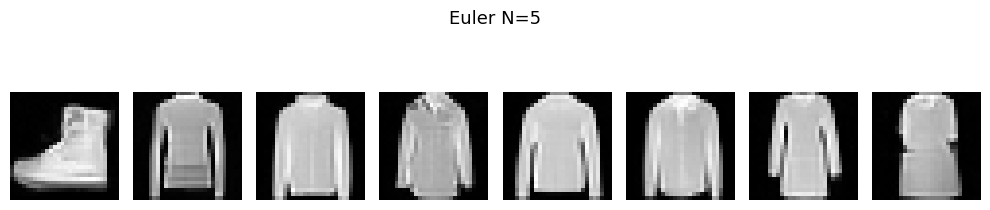

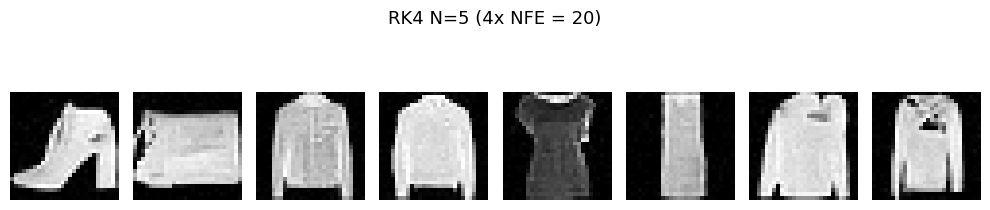

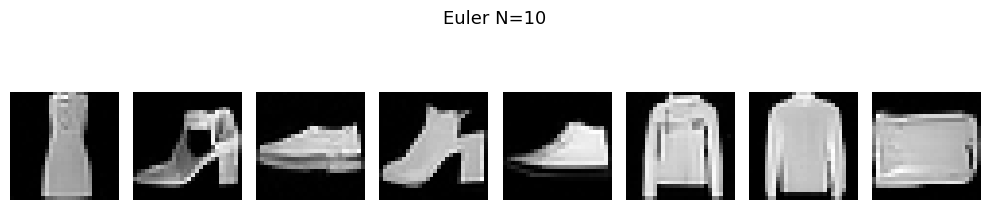

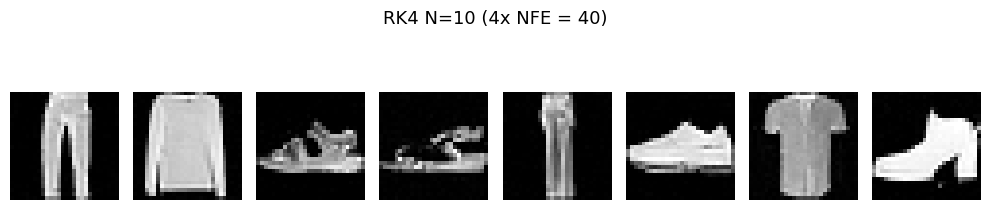

In [20]:
for n_steps in [5, 10]:
    samples_euler = rf_pixel_fashion.sample_euler(n_samples=8, n_steps=n_steps)
    samples_rk4 = rf_pixel_fashion.sample_rk4(n_samples=8, n_steps=n_steps)

    show_generated_grid(samples_euler, nrow=8,
                        title=f"Euler N={n_steps}", figsize=(10, 2.5))
    show_generated_grid(samples_rk4, nrow=8,
                        title=f"RK4 N={n_steps} (4x NFE = {n_steps*4})", figsize=(10, 2.5))

## Latent Space

Now we run rectified flow in the compressed latent space of our VAE. The idea is the same as latent diffusion models (LDM): instead of learning the flow in high-dimensional pixel space ($28 \times 28 = 784$ dims), we learn it in the 32-dimensional latent space, then decode back to pixels.

Since our VAE latent is a flat vector (not a spatial feature map), we use an MLP instead of the U-Net to predict the velocity field.

### Helpers

#### MLP Velocity Network

In [21]:
class MLPVelocity(nn.Module):
    """
    MLP-based velocity predictor for latent-space rectified flow
    Takes a latent vector z_t and time t, outputs the predicted velocity v(z_t, t)
    """
    def __init__(self, latent_dim: int = 32, hidden_dim: int = 512, time_dim: int = 128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.net = nn.Sequential(
            nn.Linear(latent_dim + time_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        z: (B, latent_dim) current position in latent space
        t: (B,) time in [0, 1] (scaled internally for embedding)
        """
        t_emb = self.time_mlp(t * 1000) # scale for sinusoidal embedding range
        h = torch.cat([z, t_emb], dim=-1)
        return self.net(h)

#### Pre-encode Dataset

To avoid running the VAE encoder during every training step, the entire dataset is being pre-encoded into latent vectors and store them.

In [22]:
@torch.no_grad()
def encode_dataset(vae: ConvVAE, loader: DataLoader, device: str) -> TensorDataset:
    """Encode all images in a DataLoader into VAE latent vectors"""
    vae.eval()
    all_z = []
    for x, _ in tqdm(loader, desc="Encoding dataset"):
        x_01 = (x.to(device) + 1) / 2 # [-1,1] -> [0,1] for the VAE
        z = vae.encode(x_01)
        all_z.append(z.cpu())
    all_z = torch.cat(all_z, dim=0)
    print(f"Encoded {all_z.shape[0]} images -> latent shape {all_z.shape[1:]}")
    return TensorDataset(all_z)

# MNIST Digits
latent_train_ds = encode_dataset(vae, train_digits, device)
latent_val_ds = encode_dataset(vae, val_digits, device)
latent_train_loader = DataLoader(latent_train_ds, batch_size=256, shuffle=True)
latent_val_loader = DataLoader(latent_val_ds, batch_size=256, shuffle=False)

# FashionMNIST
latent_fashion_train_ds = encode_dataset(vae, train_fashion, device)
latent_fashion_val_ds = encode_dataset(vae, val_fashion, device)
latent_fashion_train_loader = DataLoader(latent_fashion_train_ds, batch_size=256, shuffle=True)
latent_fashion_val_loader = DataLoader(latent_fashion_val_ds, batch_size=256, shuffle=False)

Encoding dataset:   0%|          | 0/422 [00:00<?, ?it/s]

Encoded 54000 images -> latent shape torch.Size([32])


Encoding dataset:   0%|          | 0/47 [00:00<?, ?it/s]

Encoded 6000 images -> latent shape torch.Size([32])


Encoding dataset:   0%|          | 0/422 [00:00<?, ?it/s]

Encoded 54000 images -> latent shape torch.Size([32])


Encoding dataset:   0%|          | 0/47 [00:00<?, ?it/s]

Encoded 6000 images -> latent shape torch.Size([32])


In [23]:
# sanity check: latent satistics should be roughly standard normal if VAE is well trained
sample_z = latent_train_ds.tensors[0][:1000]
print(f"Latent mean: {sample_z.mean():.3f}, std: {sample_z.std():.3f}")
print(f"Latent range: [{sample_z.min():.2f}, {sample_z.max():.2f}]")

Latent mean: 0.007, std: 0.566
Latent range: [-3.56, 3.34]


## Latent Rectified Flow

In [24]:
class RectifiedFlowLatent:
    """
    Rectified Flow in the VAE latent space

    Trains an MLP velocity model to transport N(0,I) -> encoded data distribution
    Uses the VAE decoder for final image generation
    """

    def __init__(self, velocity_model: MLPVelocity, vae: ConvVAE, device: str = "cuda"):
        self.model = velocity_model.to(device)
        self.vae = vae.to(device)
        self.vae.eval()
        self.device = device
        self.latent_dim = vae.latent_dim

    def compute_loss(self, z1: torch.Tensor) -> torch.Tensor:
        """Compute rectified flow loss in latent space"""
        B = z1.shape[0]
        z0 = torch.randn_like(z1)
        t = torch.rand(B, device=self.device)

        # linear interpolation in latent space
        z_t = t[:, None] * z1 + (1 - t[:, None]) * z0

        # target velocity
        target = z1 - z0

        # predict velocity
        v_pred = self.model(z_t, t)

        return F.mse_loss(v_pred, target)

    @torch.no_grad()
    def sample_euler(
        self,
        n_samples: int,
        n_steps: int = 10,
        return_images: bool = True,
        return_trajectory: bool = False,
    ) -> torch.Tensor:
        """Sample latents via Euler, optionally decode to images"""
        self.model.eval()
        dt = 1.0 / n_steps

        z = torch.randn(n_samples, self.latent_dim, device=self.device)
        trajectory = [z.cpu()] if return_trajectory else None

        for i in range(n_steps):
            t = torch.ones(n_samples, device=self.device) * (i * dt)
            v = self.model(z, t)
            z = z + v * dt
            if return_trajectory:
                trajectory.append(z.cpu())

        if return_images:
            images = self.vae.decode(z)
            images = images * 2 - 1 # convert to [-1, 1]
            if return_trajectory:
                return images, trajectory
            return images

        if return_trajectory:
            return z, trajectory
        return z

In [25]:
def train_rectified_flow_latent(
    rf: RectifiedFlowLatent,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 50,
    lr: float = 1e-3,
    device: str = "cuda",
) -> dict:
    """Train the latent-space rectified flow model"""
    optimizer = torch.optim.Adam(rf.model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        rf.model.train()
        epoch_loss, n = 0, 0

        pbar = tqdm(train_loader, desc=f"RF-Latent Epoch {epoch+1}/{epochs}")
        for (z1,) in pbar:
            z1 = z1.to(device)
            loss = rf.compute_loss(z1)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        # validation
        rf.model.eval()
        val_loss_sum, val_n = 0, 0
        with torch.no_grad():
            for (z1,) in val_loader:
                z1 = z1.to(device)
                loss = rf.compute_loss(z1)
                val_loss_sum += loss.item()
                val_n += 1

        avg_train = epoch_loss / n
        avg_val = val_loss_sum / val_n
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        print(f"  => train_loss: {avg_train:.4f}  val_loss: {avg_val:.4f}")

    return history

### MNIST Digits

#### Training

Latent velocity MLP parameters: 660,256


RF-Latent Epoch 1/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.7112  val_loss: 0.6498


RF-Latent Epoch 2/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.6422  val_loss: 0.6365


...

  => train_loss: 0.5688  val_loss: 0.5734


RF-Latent Epoch 49/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.5682  val_loss: 0.5780


RF-Latent Epoch 50/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.5678  val_loss: 0.5689


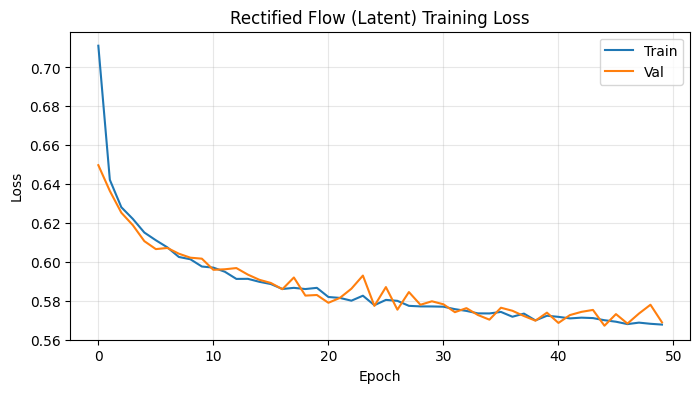

In [26]:
RF_LATENT_EPOCHS = 50

latent_velocity = MLPVelocity(latent_dim=VAE_LATENT_DIM, hidden_dim=512, time_dim=128).to(device)
rf_latent = RectifiedFlowLatent(latent_velocity, vae, device=device)

print(f"Latent velocity MLP parameters: {sum(p.numel() for p in latent_velocity.parameters()):,}")

rf_latent_history = train_rectified_flow_latent(
    rf_latent, latent_train_loader, latent_val_loader,
    epochs=RF_LATENT_EPOCHS, lr=1e-3, device=device,
)
plot_losses(rf_latent_history["train_loss"], rf_latent_history["val_loss"],
            "Rectified Flow (Latent) Training Loss")

#### Sampling

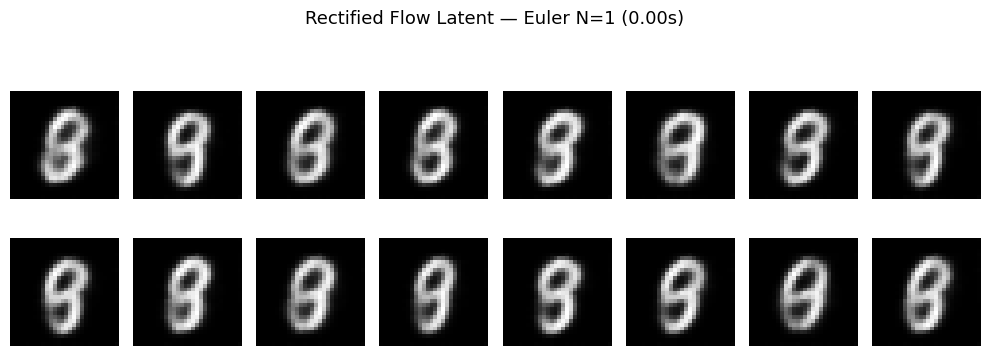

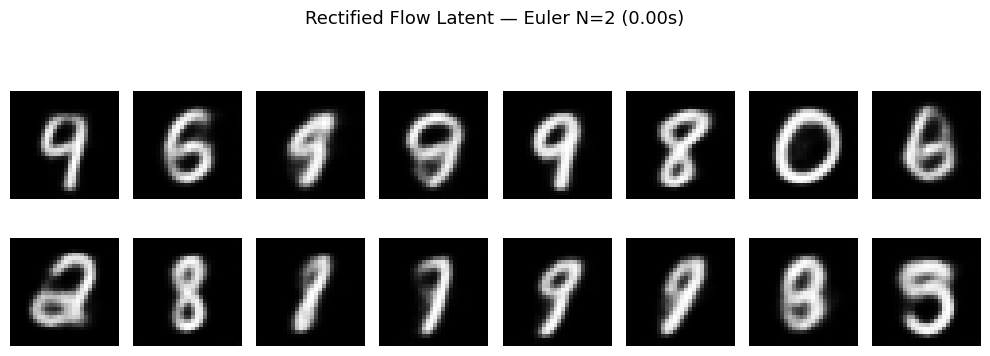

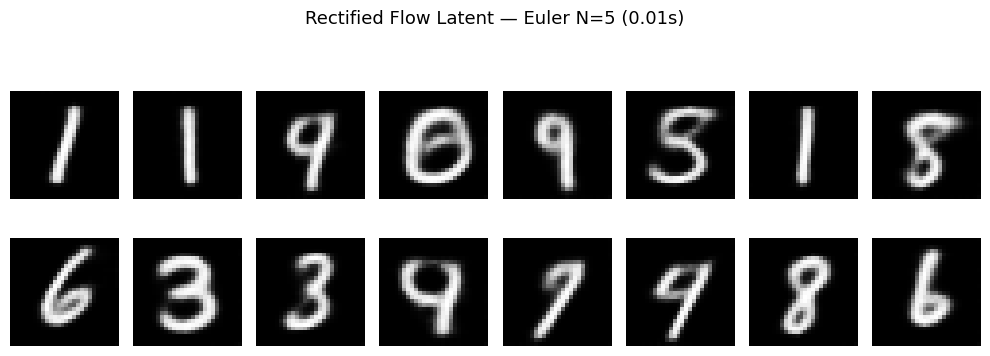

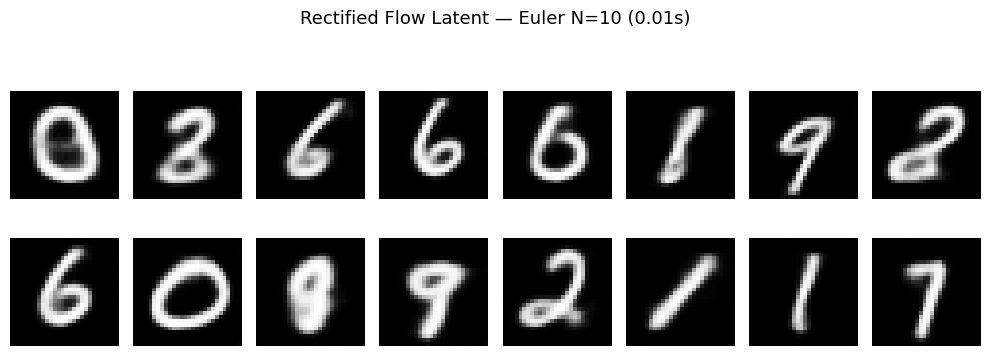

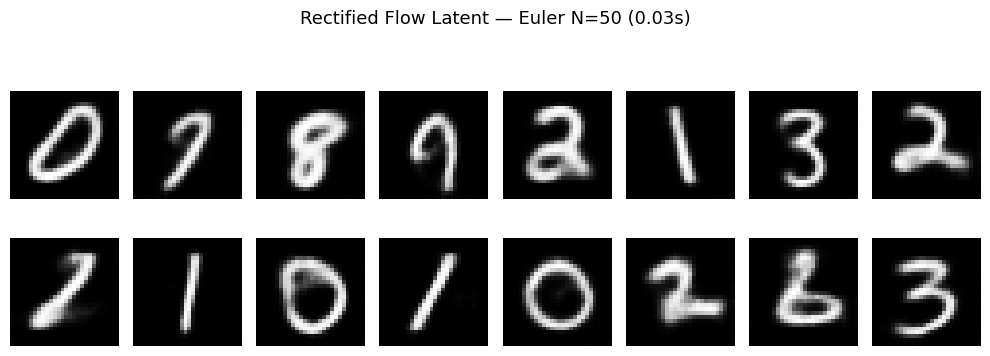

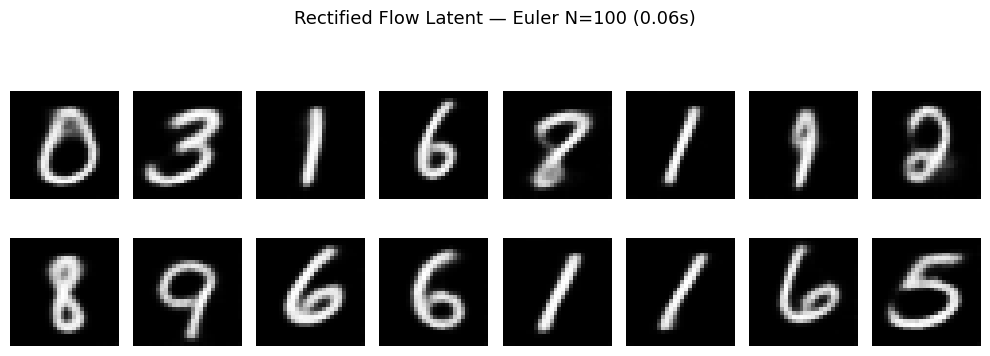

In [27]:
for n_steps in [1, 2, 5, 10, 50, 100]:
    t0 = time.time()
    samples = rf_latent.sample_euler(n_samples=16, n_steps=n_steps)
    elapsed = time.time() - t0
    show_generated_grid(
        samples, nrow=8,
        title=f"Rectified Flow Latent — Euler N={n_steps} ({elapsed:.2f}s)",
        figsize=(10, 4),
    )

### FashionMNIST

#### Training

RF-Latent Epoch 1/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.5469  val_loss: 0.4862


RF-Latent Epoch 2/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.4732  val_loss: 0.4636


RF-Latent Epoch 3/50:   0%|          | 0/211 [00:00<?, ?it/s]

...

  => train_loss: 0.4106  val_loss: 0.4132


RF-Latent Epoch 49/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.4125  val_loss: 0.4138


RF-Latent Epoch 50/50:   0%|          | 0/211 [00:00<?, ?it/s]

  => train_loss: 0.4109  val_loss: 0.4106


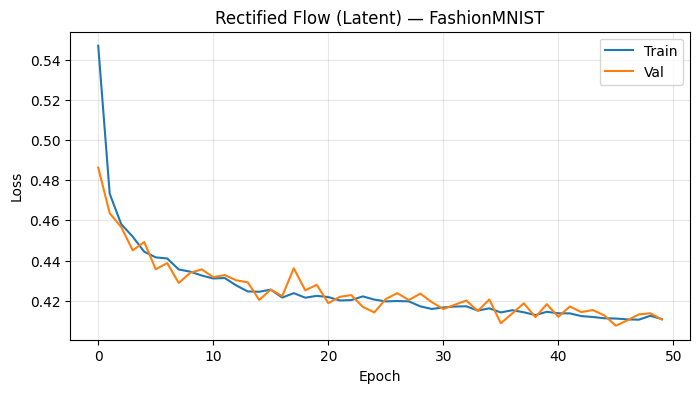

In [29]:
latent_velocity_fashion = MLPVelocity(latent_dim=VAE_LATENT_DIM, hidden_dim=512, time_dim=128).to(device)
rf_latent_fashion = RectifiedFlowLatent(latent_velocity_fashion, vae_fashion, device=device)

rf_latent_fashion_history = train_rectified_flow_latent(
    rf_latent_fashion, latent_fashion_train_loader, latent_fashion_val_loader,
    epochs=RF_LATENT_EPOCHS, lr=1e-3, device=device,
)
plot_losses(rf_latent_fashion_history["train_loss"], rf_latent_fashion_history["val_loss"],
            "Rectified Flow (Latent) — FashionMNIST")

#### Sampling

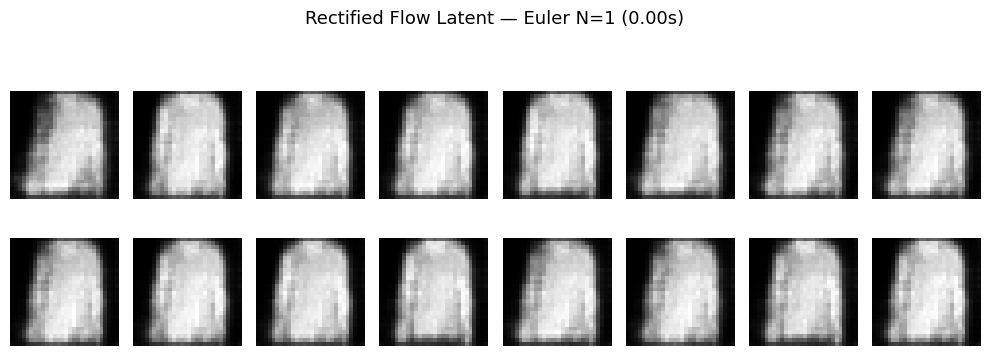

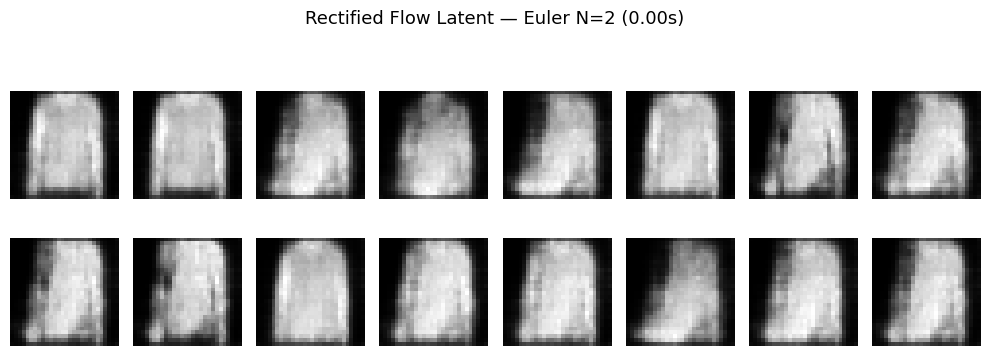

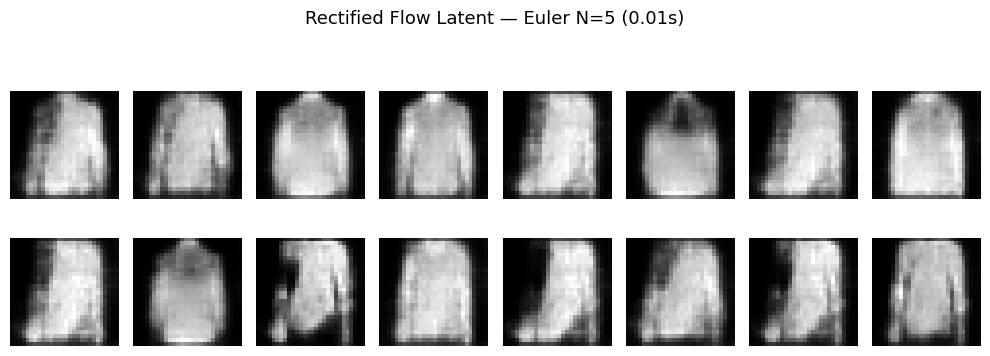

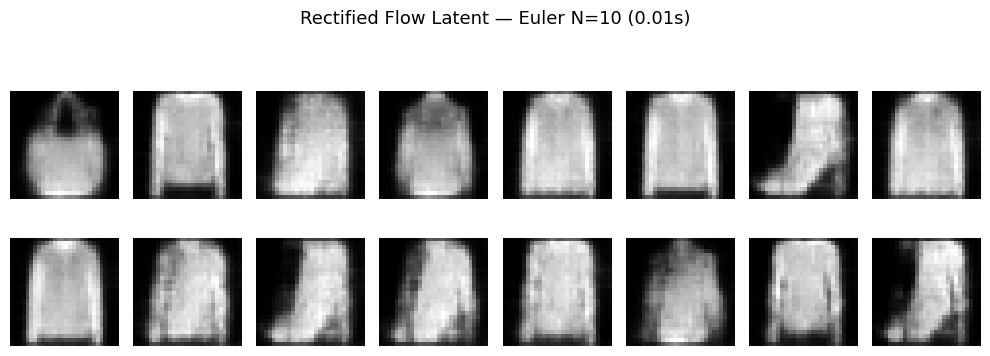

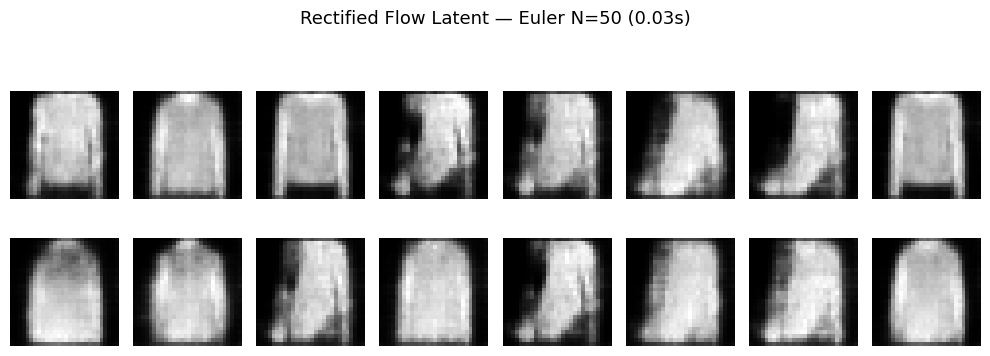

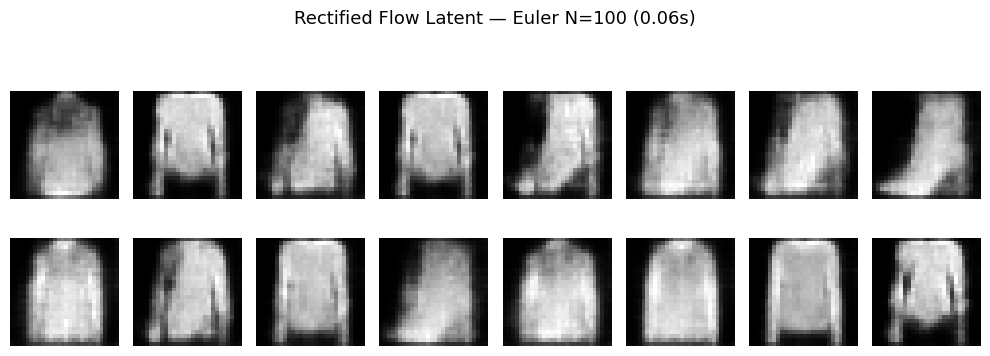

In [30]:
for n_steps in [1, 2, 5, 10, 50, 100]:
    t0 = time.time()
    samples = rf_latent_fashion.sample_euler(n_samples=16, n_steps=n_steps)
    elapsed = time.time() - t0
    show_generated_grid(
        samples, nrow=8,
        title=f"Rectified Flow Latent — Euler N={n_steps} ({elapsed:.2f}s)",
        figsize=(10, 4),
    )

# Reflow

Takes the trained 1-rectified flow, generate paired data $(Z_0, Z_1)$ by simulating it, then train a new flow on these pairs. The new flow will have straighter trajectories.

## Helpers

### Reflow Pairs Generation

In [31]:
@torch.no_grad()
def generate_reflow_pairs_pixel(
    rf: RectifiedFlowPixel,
    n_pairs: int = 10000,
    n_steps: int = 100,
    batch_size: int = 256,
    shape: Tuple = (1, 28, 28),
    device: str = "cuda",
) -> TensorDataset:
    """Generate (z0, z1) pairs by simulating the trained rectified flow"""
    rf.model.eval()
    all_z0, all_z1 = [], []

    n_batches = (n_pairs + batch_size - 1) // batch_size
    for _ in tqdm(range(n_batches), desc="Generating reflow pairs"):
        B = min(batch_size, n_pairs - len(all_z0) * batch_size if all_z0 else batch_size)
        z0 = torch.randn(B, *shape, device=device)
        z = z0.clone()
        dt = 1.0 / n_steps

        for i in range(n_steps):
            t = torch.ones(B, device=device) * (i * dt)
            v = rf.model(z, t * 1000)
            z = z + v * dt

        all_z0.append(z0.cpu())
        all_z1.append(z.cpu())

    all_z0 = torch.cat(all_z0, dim=0)[:n_pairs]
    all_z1 = torch.cat(all_z1, dim=0)[:n_pairs]
    print(f"Generated {all_z0.shape[0]} reflow pairs")
    return TensorDataset(all_z0, all_z1)

### Training

In [32]:
def train_reflow_pixel(
    model: UNet,
    reflow_dataset: TensorDataset,
    epochs: int = 20,
    lr: float = 2e-4,
    batch_size: int = 128,
    device: str = "cuda",
) -> Tuple[RectifiedFlowPixel, dict]:
    """
    Train a new rectified flow on reflow pairs (z0, z1)
    Instead of sampling x0 ~ N(0,I) fresh, we use the specific paired (z0, z1) from the previous flow
    """
    model = model.to(device)
    rf = RectifiedFlowPixel(model, device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(reflow_dataset, batch_size=batch_size, shuffle=True)
    history = {"train_loss": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n = 0, 0
        pbar = tqdm(loader, desc=f"Reflow Epoch {epoch+1}/{epochs}")

        for z0, z1 in pbar:
            z0, z1 = z0.to(device), z1.to(device)
            B = z0.shape[0]

            t = torch.rand(B, device=device)
            z_t = t[:, None, None, None] * z1 + (1 - t[:, None, None, None]) * z0
            target = z1 - z0

            v_pred = model(z_t, t * 1000)
            loss = F.mse_loss(v_pred, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        history["train_loss"].append(epoch_loss / n)
        print(f"  => train_loss: {epoch_loss/n:.4f}")

    return rf, history

In [33]:
REFLOW_N_PAIRS = 20000
REFLOW_SIM_STEPS = 100
REFLOW_EPOCHS = 20

print("Generating reflow pairs from 1-rectified flow")
reflow_dataset = generate_reflow_pairs_pixel(
    rf_pixel, n_pairs=REFLOW_N_PAIRS, n_steps=REFLOW_SIM_STEPS, device=device,
)

print("\nTraining 2-rectified flow")
rf2_model = UNet(in_ch=1, base_ch=64, time_dim=256, dropout=0.1).to(device)
rf2_pixel, rf2_history = train_reflow_pixel(
    rf2_model, reflow_dataset, epochs=REFLOW_EPOCHS, lr=2e-4, device=device,
)

Generating reflow pairs from 1-rectified flow


Generating reflow pairs:   0%|          | 0/79 [00:00<?, ?it/s]

Generated 20000 reflow pairs

Training 2-rectified flow


Reflow Epoch 1/20:   0%|          | 0/157 [00:00<?, ?it/s]

  => train_loss: 0.2532


...

  => train_loss: 0.0163


Reflow Epoch 19/20:   0%|          | 0/157 [00:00<?, ?it/s]

  => train_loss: 0.0160


Reflow Epoch 20/20:   0%|          | 0/157 [00:00<?, ?it/s]

  => train_loss: 0.0159


### Experiments

#### 1-RF vs 2-RF Comparison

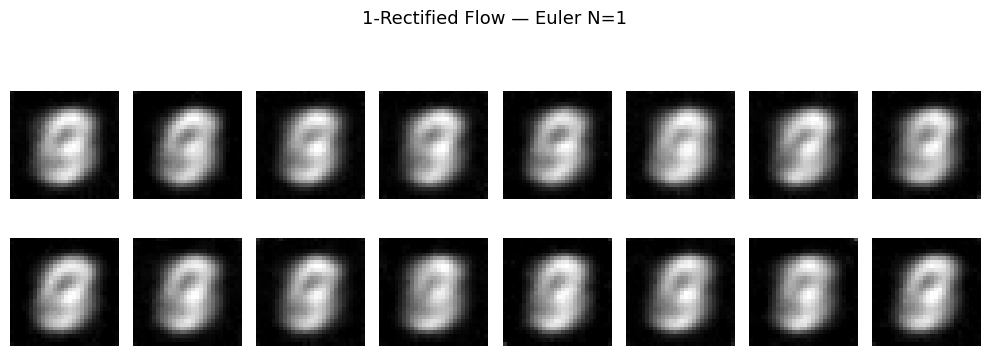

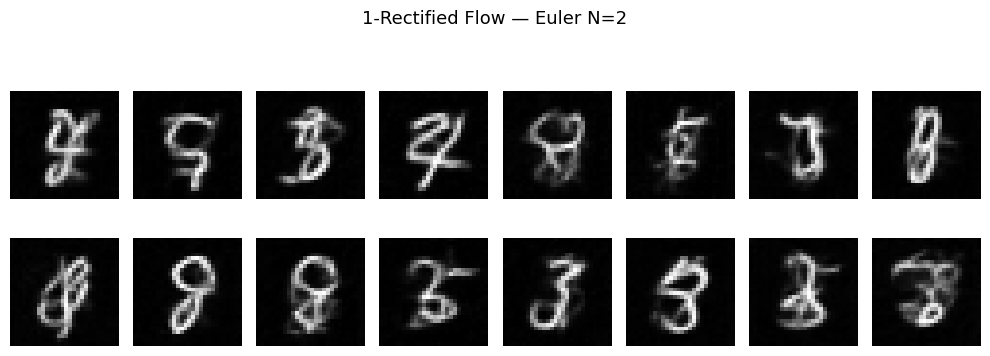

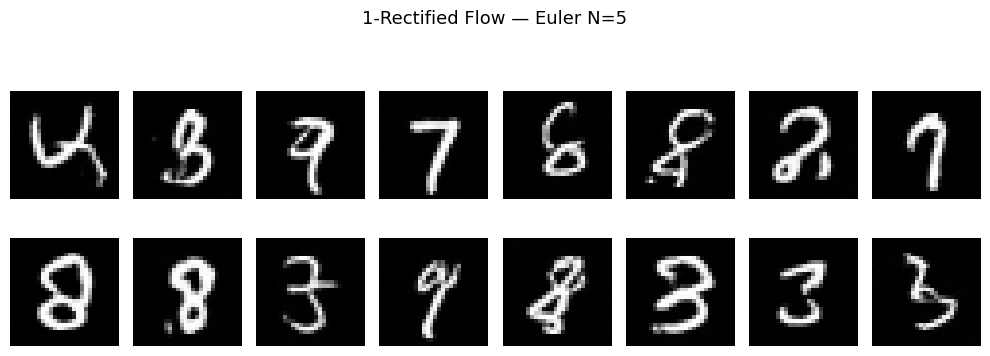

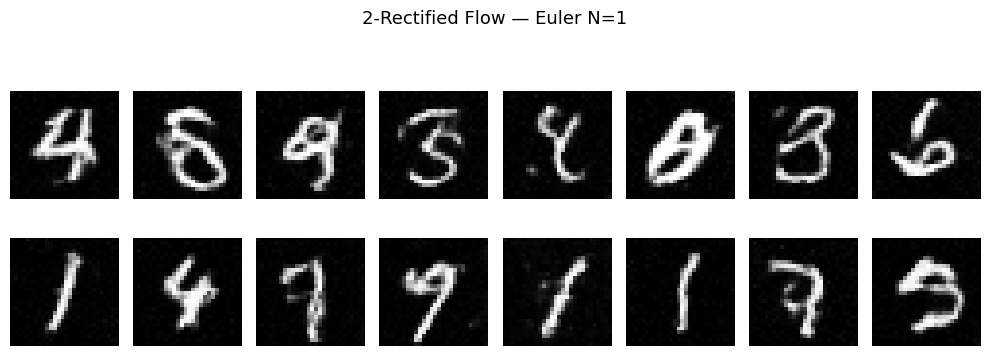

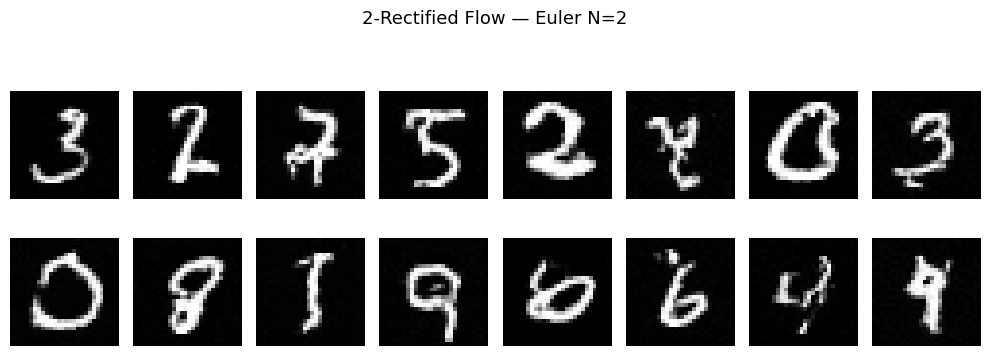

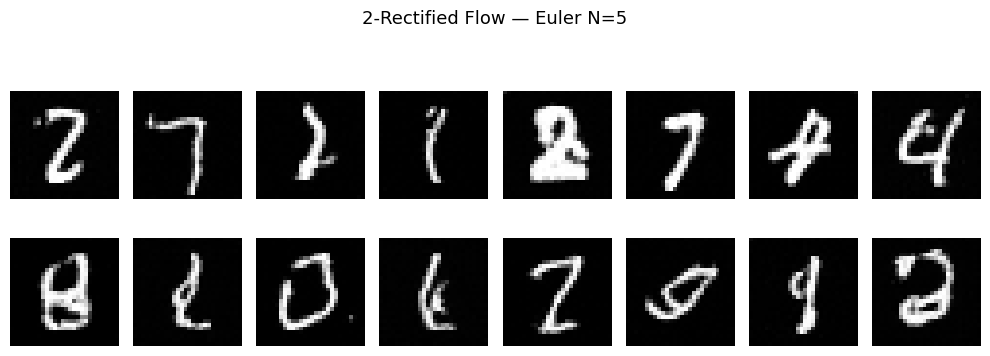

In [34]:
for n_steps in [1, 2, 5]:
    samples = rf_pixel.sample_euler(n_samples=16, n_steps=n_steps)
    show_generated_grid(samples, nrow=8,
                        title=f"1-Rectified Flow — Euler N={n_steps}", figsize=(10, 4))

for n_steps in [1, 2, 5]:
    samples = rf2_pixel.sample_euler(n_samples=16, n_steps=n_steps)
    show_generated_grid(samples, nrow=8,
                        title=f"2-Rectified Flow — Euler N={n_steps}", figsize=(10, 4))

#### Straightness Measurement

Quantifies how straight the trajectories are by computing the [straightness measure](https://arxiv.org/pdf/2209.03003#page=7) from the paper:

$$S(\mathbf{Z}) = \int_0^1 \mathbb{E}\left[\left\|(Z_1 - Z_0) - \dot{Z}_t\right\|^2\right] dt$$

Straightness S(Z):
  1-Rectified Flow: 55.1328
  2-Rectified Flow: 3.1326
  Reduction: 94.3%


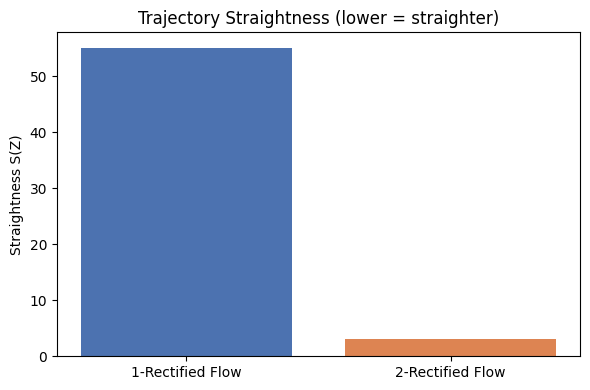

In [35]:
@torch.no_grad()
def measure_straightness(
    rf: RectifiedFlowPixel,
    n_samples: int = 256,
    n_steps: int = 100,
    shape: Tuple = (1, 28, 28),
    device: str = "cuda",
) -> float:
    """Estimate the straightness measure S(Z) (S = 0 perfectly straight; larger means curved)"""
    rf.model.eval()
    dt = 1.0 / n_steps

    z = torch.randn(n_samples, *shape, device=device)
    z0 = z.clone()

    # first, simulate to get z1
    z_sim = z.clone()
    for i in range(n_steps):
        t = torch.ones(n_samples, device=device) * (i * dt)
        v = rf.model(z_sim, t * 1000)
        z_sim = z_sim + v * dt
    z1 = z_sim

    # ideal constant velocity for straight paths
    ideal_velocity = z1 - z0

    # re-simulate and compare actual velocity to ideal
    z_sim = z0.clone()
    total_deviation = 0.0
    for i in range(n_steps):
        t = torch.ones(n_samples, device=device) * (i * dt)
        v = rf.model(z_sim, t * 1000)
        deviation = ((v - ideal_velocity) ** 2).sum(dim=(1, 2, 3)).mean()
        total_deviation += deviation.item() * dt
        z_sim = z_sim + v * dt

    return total_deviation


s1 = measure_straightness(rf_pixel, n_samples=256, n_steps=100, device=device)
s2 = measure_straightness(rf2_pixel, n_samples=256, n_steps=100, device=device)

print(f"Straightness S(Z):")
print(f"  1-Rectified Flow: {s1:.4f}")
print(f"  2-Rectified Flow: {s2:.4f}")
print(f"  Reduction: {(1 - s2/s1)*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["1-Rectified Flow", "2-Rectified Flow"], [s1, s2], color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Straightness S(Z)")
ax.set_title("Trajectory Straightness (lower = straighter)")
plt.tight_layout()
plt.show()

# Comparison & Results

## Timing Comparison

In [36]:
def time_sampling(sample_fn, n_samples, n_runs=3, **kwargs):
    """Time a sampling function over multiple runs"""
    times = []
    for _ in range(n_runs):
        torch.cuda.synchronize() if device == "cuda" else None
        t0 = time.time()
        _ = sample_fn(n_samples=n_samples, **kwargs)
        torch.cuda.synchronize() if device == "cuda" else None
        times.append(time.time() - t0)
    return np.mean(times), np.std(times)


N_TIMING_SAMPLES = 64

timing_results = {}

# Rectified Flow (pixel) — various steps
for n_steps in [1, 2, 5, 10, 50, 100]:
    mean_t, std_t = time_sampling(rf_pixel.sample_euler, N_TIMING_SAMPLES, n_steps=n_steps)
    timing_results[f"RF-Pixel Euler N={n_steps}"] = (mean_t, std_t, n_steps)

# Rectified Flow (latent) — various steps
for n_steps in [1, 2, 5, 10, 50, 100]:
    mean_t, std_t = time_sampling(rf_latent.sample_euler, N_TIMING_SAMPLES, n_steps=n_steps)
    timing_results[f"RF-Latent Euler N={n_steps}"] = (mean_t, std_t, n_steps)

# 2-Rectified Flow — few steps
for n_steps in [1, 2, 5]:
    mean_t, std_t = time_sampling(rf2_pixel.sample_euler, N_TIMING_SAMPLES, n_steps=n_steps)
    timing_results[f"2-RF-Pixel Euler N={n_steps}"] = (mean_t, std_t, n_steps)

print(f"\n{'Method':<35} {'Time (s)':<15} {'NFE':<6}")
print("-" * 56)
for method, (mean_t, std_t, nfe) in timing_results.items():
    print(f"{method:<35} {mean_t:.3f} ± {std_t:.3f}   {nfe}")


Method                              Time (s)        NFE   
--------------------------------------------------------
RF-Pixel Euler N=1                  0.017 ± 0.014   1
RF-Pixel Euler N=2                  0.014 ± 0.000   2
RF-Pixel Euler N=5                  0.033 ± 0.000   5
RF-Pixel Euler N=10                 0.066 ± 0.000   10
RF-Pixel Euler N=50                 0.331 ± 0.003   50
RF-Pixel Euler N=100                0.666 ± 0.006   100
RF-Latent Euler N=1                 0.003 ± 0.002   1
RF-Latent Euler N=2                 0.002 ± 0.000   2
RF-Latent Euler N=5                 0.004 ± 0.000   5
RF-Latent Euler N=10                0.007 ± 0.000   10
RF-Latent Euler N=50                0.034 ± 0.002   50
RF-Latent Euler N=100               0.063 ± 0.000   100
2-RF-Pixel Euler N=1                0.008 ± 0.000   1
2-RF-Pixel Euler N=2                0.014 ± 0.000   2
2-RF-Pixel Euler N=5                0.034 ± 0.000   5


## Speed Comparison

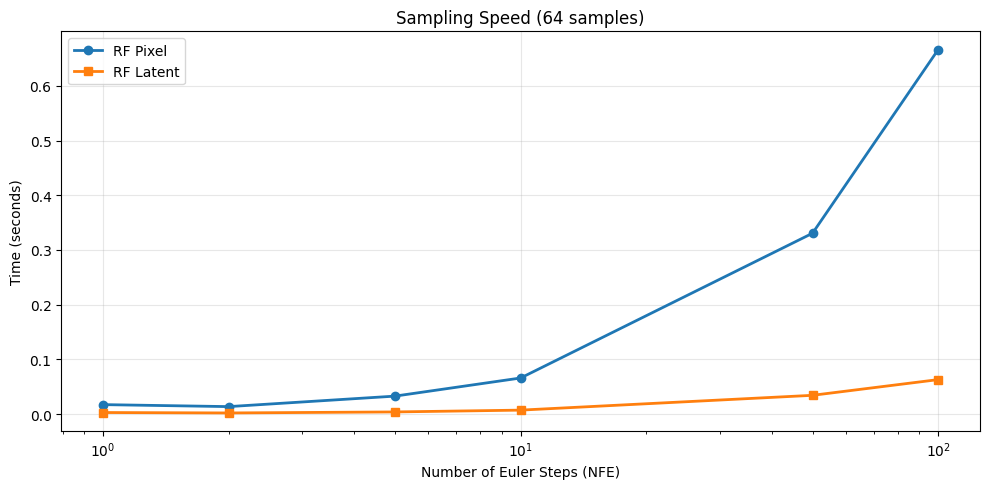

In [37]:
methods_pixel = [(k, v) for k, v in timing_results.items() if "RF-Pixel" in k and "2-RF" not in k]
methods_latent = [(k, v) for k, v in timing_results.items() if "RF-Latent" in k]

fig, ax = plt.subplots(figsize=(10, 5))

steps_p = [v[2] for _, v in methods_pixel]
times_p = [v[0] for _, v in methods_pixel]
steps_l = [v[2] for _, v in methods_latent]
times_l = [v[0] for _, v in methods_latent]

ax.plot(steps_p, times_p, 'o-', label="RF Pixel", linewidth=2)
ax.plot(steps_l, times_l, 's-', label="RF Latent", linewidth=2)

ax.set_xlabel("Number of Euler Steps (NFE)")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Sampling Speed ({N_TIMING_SAMPLES} samples)")
ax.set_xscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Quality Comparison

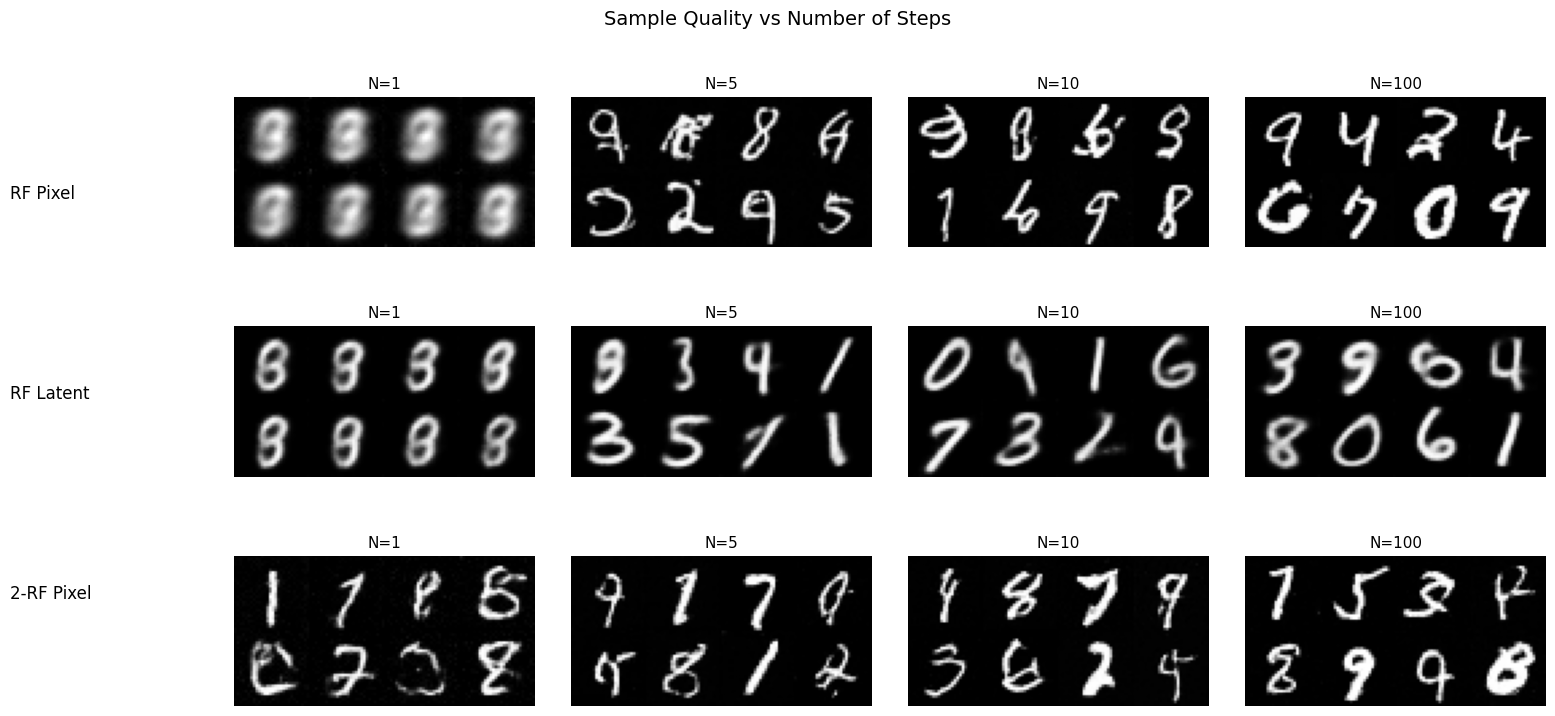

In [55]:
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
fig.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.06, wspace=0.12, hspace=0.0)

# RF-Pixel
for j, n_steps in enumerate([1, 5, 10, 100]):
    samples = rf_pixel.sample_euler(n_samples=8, n_steps=n_steps)
    samples_01 = (samples.cpu().clamp(-1, 1) + 1) / 2
    grid = samples_01[:8].reshape(2, 4, 1, 28, 28)
    img = grid.permute(0, 3, 1, 4, 2).reshape(56, 112)
    axes[0, j].imshow(img, cmap="gray")
    axes[0, j].set_title(f"N={n_steps}", fontsize=11)
    axes[0, j].axis("off")

# RF-Latent
for j, n_steps in enumerate([1, 5, 10, 100]):
    samples = rf_latent.sample_euler(n_samples=8, n_steps=n_steps)
    samples_01 = (samples.cpu().clamp(-1, 1) + 1) / 2
    grid = samples_01[:8].reshape(2, 4, 1, 28, 28)
    img = grid.permute(0, 3, 1, 4, 2).reshape(56, 112)
    axes[1, j].imshow(img, cmap="gray")
    axes[1, j].set_title(f"N={n_steps}", fontsize=11)
    axes[1, j].axis("off")

# 2-RF-Pixel
for j, n_steps in enumerate([1, 5, 10, 100]):
    samples = rf2_pixel.sample_euler(n_samples=8, n_steps=n_steps)
    samples_01 = (samples.cpu().clamp(-1, 1) + 1) / 2
    grid = samples_01[:8].reshape(2, 4, 1, 28, 28)
    img = grid.permute(0, 3, 1, 4, 2).reshape(56, 112)
    axes[2, j].imshow(img, cmap="gray")
    axes[2, j].set_title(f"N={n_steps}", fontsize=11)
    axes[2, j].axis("off")

fig.text(0.02, 0.75, "RF Pixel", fontsize=12, va="center", ha="left")
fig.text(0.02, 0.50, "RF Latent", fontsize=12, va="center", ha="left")
fig.text(0.02, 0.25, "2-RF Pixel", fontsize=12, va="center", ha="left")

fig.suptitle("Sample Quality vs Number of Steps", fontsize=14)
plt.show()

## Convergence Comparison

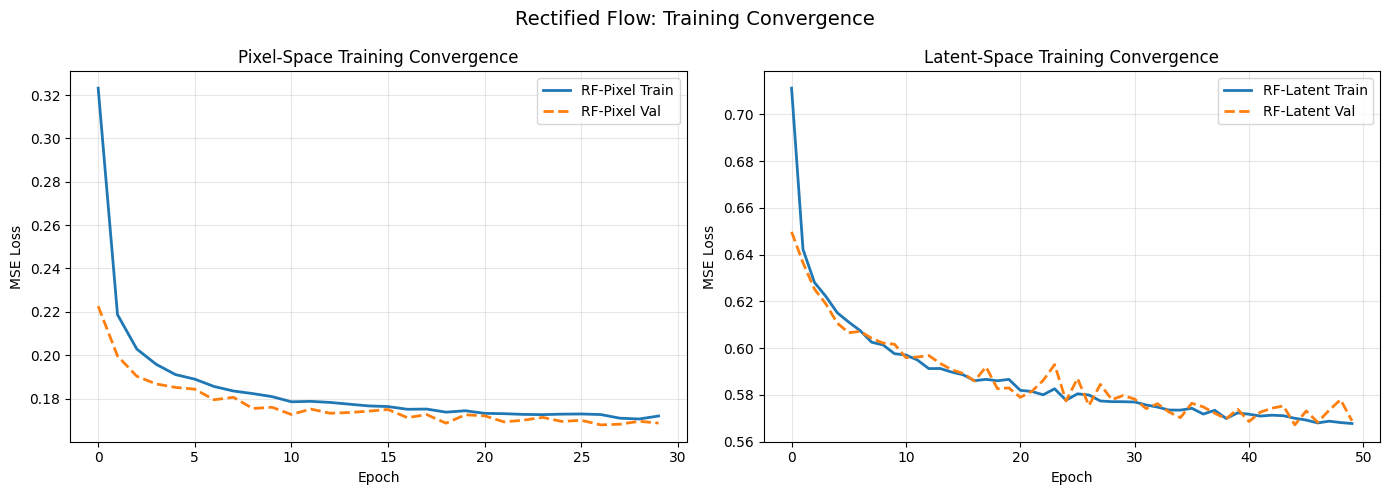

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pixel space losses
axes[0].plot(rf_pixel_history["train_loss"], label="RF-Pixel Train", linewidth=2)
axes[0].plot(rf_pixel_history["val_loss"], label="RF-Pixel Val", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Pixel-Space Training Convergence")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# latent space losses
axes[1].plot(rf_latent_history["train_loss"], label="RF-Latent Train", linewidth=2)
axes[1].plot(rf_latent_history["val_loss"], label="RF-Latent Val", linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Latent-Space Training Convergence")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Rectified Flow: Training Convergence", fontsize=14)
plt.tight_layout()
plt.show()

## Velocity Field Accuracy

Visualize what the velocity field actually predicts; given an interpolated input $X_t$, how well does $v_\theta(X_t, t)$ match the true direction $(X_1 - X_0)$?

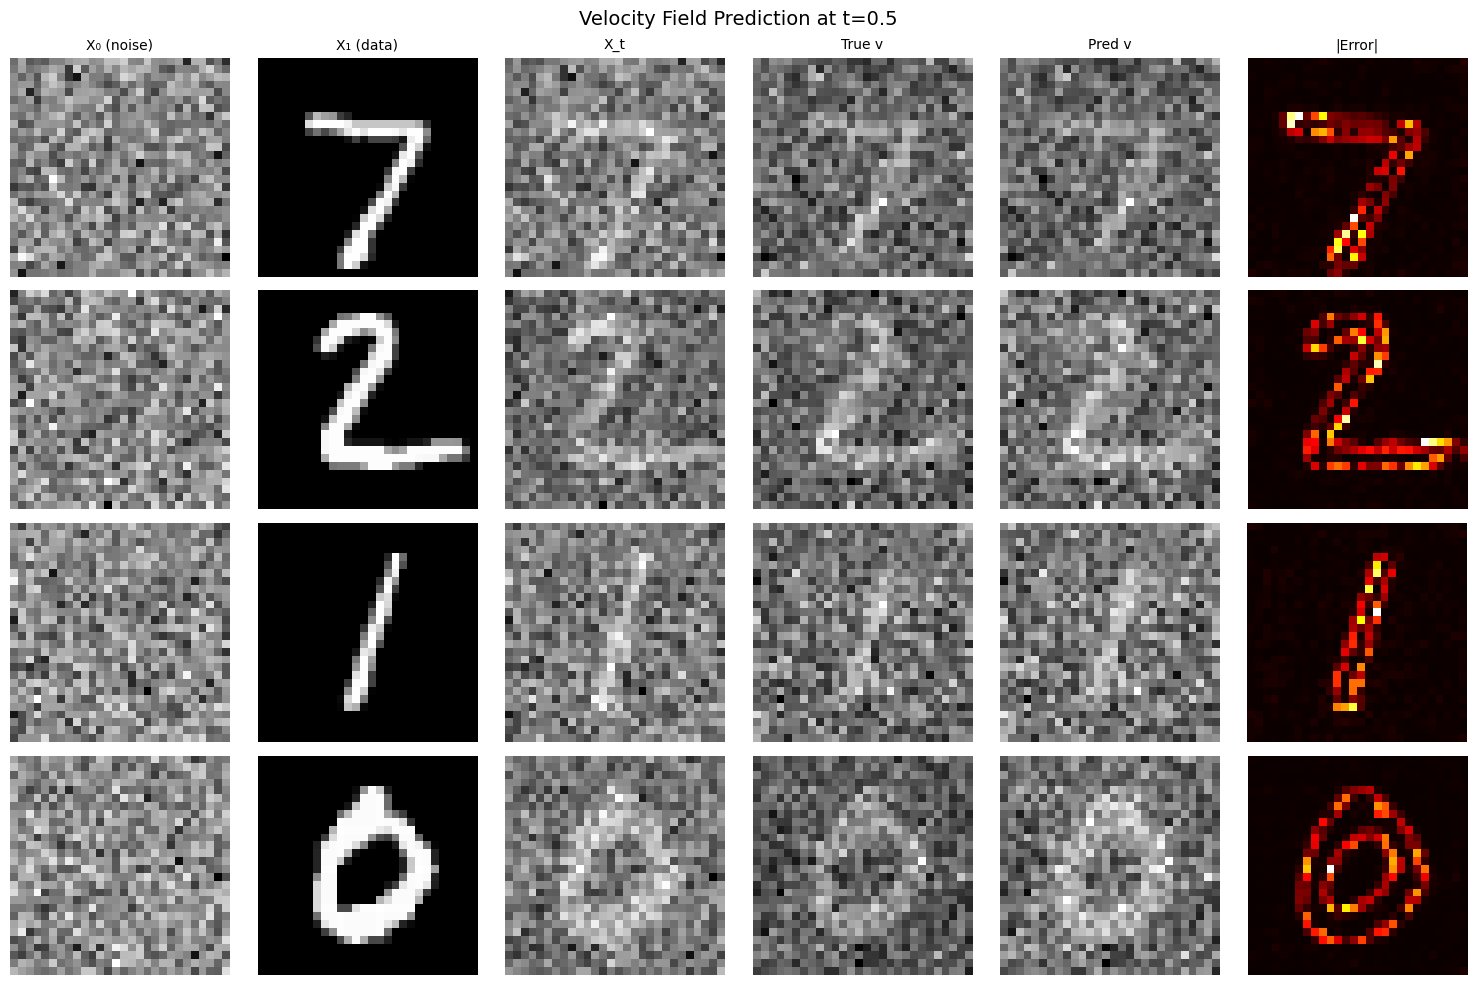

In [40]:
rf_pixel.model.eval()

x1, _ = next(iter(test_digits))
x1 = x1[:4].to(device)
x0 = torch.randn_like(x1)

fig, axes = plt.subplots(4, 6, figsize=(15, 10))
col_labels = ["X₀ (noise)", "X₁ (data)", "X_t", "True v", "Pred v", "|Error|"]

for i in range(4):
    for t_val in [0.5]: # show at midpoint
        t = torch.ones(1, device=device) * t_val
        x_t = t_val * x1[i:i+1] + (1 - t_val) * x0[i:i+1]
        true_v = x1[i:i+1] - x0[i:i+1]
        pred_v = rf_pixel.model(x_t, t * 1000)
        error = (true_v - pred_v).abs()

        imgs = [x0[i], x1[i], x_t[0], true_v[0], pred_v[0], error[0]]
        for j, img in enumerate(imgs):
            im = img.detach().cpu().squeeze()
            if j == 5: # error map
                axes[i, j].imshow(im, cmap="hot")
            else:
                axes[i, j].imshow(im, cmap="gray")
            axes[i, j].axis("off")
            if i == 0:
                axes[i, j].set_title(col_labels[j], fontsize=10)

fig.suptitle("Velocity Field Prediction at t=0.5", fontsize=14)
plt.tight_layout()
plt.show()

# Results Discussion

## Internal Analysis

### Training Convergence

It was smooth and stable for both pixel and latent variants; no loss spikes, no mode collapse during training, no sensitivity to learning rate. The pixel-space model converged to an MSE of ~0.17 within 30 epochs, while the latent-space MLP settled around 0.57 in 50 epochs. The higher absolute loss for the latent model is expected: the VAE latent vectors have a different scale and structure than normalized pixel values, so the raw MSE numbers are not directly comparable.

### Sample Quality

Scales predictably with the number of Euler steps. At N=1, the pixel-space 1-rectified flow produces recognizable but blurry digit-like shapes, like  it is trying to generate digits, but the images look like averages of multiple possible outputs. This is exactly what the theory predicts: at N=1, the model outputs $Z_0 + v(Z_0, 0)$, which is the conditional mean of possible endpoints. With more steps (N=5, 10), the diversity and sharpness improve dramatically as the ODE solver can follow the actual curved trajectories more faithfully. By N=100, the pixel-space samples are sharp and diverse.

### $N=1$ Mode

The latent-space model surprised us at N=1. Even with a single Euler step, the latent RF produces noticeably sharper digits than its pixel-space counterpart. The 32-dimensional latent space is far more compact and structured than 784-dimensional pixel space, so the velocity field is easier to learn and the linear approximation (one Euler step) is more accurate in this lower-dimensional manifold.

Both models at N=1 show a strong bias toward certain digits (8s and 9s are overrepresented). This is not a training failure, but a geometric consequence of one-step generation. The velocity at $t=0$ is essentially $\mathbb{E}[X_1 - X_0 \mid X_0 = z]$, which averages over all possible data endpoints. With more steps, the ODE can differentiate between trajectories headed toward different digits, and diversity recovers.

### Reflow

The straightness metric dropped from 55.13 (1-rectified flow) to 3.13 (2-rectified flow), so it's a 94.3% reduction. The practical impact is equally clear in the quality comparison grid: 2-RF at N=1 produces sharp, diverse, recognizable digits, while 1-RF at N=1 produces blurry averages. The 2-RF samples at N=1 are arguably comparable to 1-RF samples at N=10 or higher. This confirms the central claim of the paper, that reflow straightens trajectories enough that one or two Euler steps suffice.

The velocity field visualization reveals where the model struggles. The error maps show that prediction errors concentrate along digit edge, because the velocity field $v^*(x, t) = \mathbb{E}[X_1 - X_0 \mid X_t = x]$ must average over many possible digit shapes, and the edges are exactly where different digits disagree most. A larger model or longer training would help here.

### Speed Comparison

The latent model is roughly 10x faster than the pixel model at every step count, which is the expected ratio given the dimensionality reduction ($784 / 32 \approx 24$x fewer dimensions, partially offset by the VAE decode cost). At N=100, pixel RF takes ~0.67s for 64 samples vs ~0.06s for latent RF. The scaling is approximately linear in N for both, as expected from Euler integration.

### What Worked Well

- The simplicity of rectified flow: implementation is genuinely shorter and cleaner than DDPM.
- Reflow straightening works well even with just 20k pairs and 20 epochs of training on the 2-RF. The 94.3% straightness reduction translates directly into visible quality improvements at low step counts.
- The latent-space variant converges fast and generates sharp one-step samples despite using a simple 3-layer MLP. This validates the LDM intuition that working in compressed space makes the generation problem easier.

### What Didn't Work As Expected

- The N=1 pixel-space samples are blurrier than I hoped. The paper shows clean one-step results on CIFAR-10 with distillation, but our 1-RF without distillation at N=1 is essentially an averaged blob. The distillation step (which I did not implement) seems important for crisp one-step pixel-space generation...
- The latent model shows limited digit diversity at low step counts (many samples look like 8s or 9s). The VAE's latent space geometry likely contributes: some regions are denser and attract more one-step trajectories.
- The 2-RF quality at high step counts (N=100) is slightly worse than 1-RF at N=100. This is expected. Reflow pairs are generated from the imperfect 1-RF, so the 2-RF inherits and can amplify approximation errors. The paper explicitly warns against too many reflow iterations for this reason.

### Why Results Could Be Better?

-  U-Net is relatively small (designed for 28×28 MNIST). The paper uses DDPM++ architectures on CIFAR-10 with significantly more parameters.
- 30 epochs on MNIST is modest. The paper trains for hundreds of thousands of iterations.
- The paper's best one-step results use a distillation stage after reflow, where a network is explicitly trained to map $Z_0 \to Z_1$ using LPIPS loss instead of MSE. This is crucial for perceptual sharpness.
- Reflow data volume. I generated only 20k pairs for reflow, while the paper uses 4 million pairs, which gives a much better approximation of the true coupling.

### How could results be improved?

- **Add distillation** with a perceptual loss (LPIPS) after the 2-RF stage — this should dramatically sharpen one-step samples.
- **Increase reflow pairs** to at least 100k–500k for a more faithful coupling.
- **Use a better VAE** (or a VQ-VAE) for the latent-space variant to reduce the reconstruction bottleneck.
- **Train longer** with learning rate scheduling (cosine decay) and EMA weight averaging.

## Comparison: Rectified Flow vs Diffusion (DDPM/DDIM)

### Speed Comparison

DDPM-1000 takes **6.68s** to generate 64 samples (the full 1000-step reverse chain). The most aggressive diffusion acceleration we achieved was DDIM-50 + DeepCache N=5, which reaches **0.20s** (33× speedup) while still producing recognizable digits.

Rectified flow achieves better results. RF-Pixel at N=10 takes **0.066s** (already 3× faster than the best diffusion configuration) with comparable sample quality. The 2-rectified flow at N=1 takes **0.008s**, which is **835× faster than DDPM-1000** and **25× faster than the fastest usable DDIM+DeepCache setup**. The latent RF at N=1 pushes this to **0.003s**, though the comparison is less fair since it uses a different (MLP) architecture operating in compressed space.

| Method | Time (64 samples) | Speedup vs DDPM |
|--------|-------------------|-----------------|
| DDPM-1000 | 6.68s | 1× (baseline) |
| DDPM + DC N=10 | 3.35s | 2× |
| DDIM-50 (η=1) | 0.35s | 19× |
| DDIM-10 (η=1) | 0.16s | 42× |
| DDIM-50 + DC N=5 | 0.20s | 33× |
| RF-Pixel N=10 | 0.066s | 101× |
| 2-RF-Pixel N=1 | 0.008s | 835× |
| RF-Latent N=10 | 0.007s | 954× |

The underlying reason is fully architectural. DDPM/DDIM speed improvements work along two independent axes: reduce the number of steps (DDIM), reduce the cost per step (DeepCache). The reflow procedure invests compute once at training time + optimize straighter trajectories and benefits every single inference call afterward.

### Sample Quality

Quality comparisons depend on the step budget.

**High NFE regime (50+ steps).** DDPM-1000 remains the overall quality champion, because 1000 stochastic denoising steps with a well-trained noise predictor is hard to beat on raw quality. DDIM-50 (η=1) comes close, producing clean digits with a 19× speedup. RF-Pixel at N=100 is visually competitive with DDIM-50 (η=1), though DDPM-1000 still edges them out in stroke crispness.

**Moderate NFE regime (5–10 steps).** RF-Pixel at N=5 produces recognizable, diverse digits with reasonable sharpness. DDIM-10 (η=1) also produces recognizable digits at similar speed, and the two are honestly close in quality. But the critical difference is *robustness*. DDIM quality at low step counts is sensitive to η. DDIM-50 (η=0) drifted toward thick, bloated shapes at moderate-to-high step counts. This is a failure mode that simply does not exist in rectified flow because there is no η to get wrong. RF at N=5–10 just works.

**Very low NFE regime (1–2 steps).** DDIM cannot meaningfully operate at N=1. The closest diffusion analogue would be trying a single DDPM reverse step, which produces noise. Meanwhile, 2-RF at N=1 generates sharp, diverse digits. Looking at the quality grid, 2-RF at N=1 produces samples that are roughly on par with DDIM-10 (η=1) in diversity and sharpness, but in 0.008s vs 0.16s.

The 1-RF at N=1 (without reflow) is admittedly blurry with a bias toward 8s and 9s. This is the averaging effect of one-step generation. The reflow step is what unlocks single-step sampling, and nothing in the standard DDPM/DDIM toolkit provides an equivalent mechanism.

DDIM-50 with DeepCache at aggressive intervals (N=3, N=5) combined with η=1 produced severely degraded outputs in our experiments because of the stochastic noise injection and cached features eerrors overlap.  Rectified flow has no such interaction, as there is no stochasticity in the sampling ODE.

### Training Stability and Simplicity

#### DDPM/DDIM

Require making several consequential design decisions before training begins: the noise schedule shape (linear vs cosine $\beta_t$), prediction parameterization ($\epsilon$-prediction, $x_0$-prediction, or v-prediction), and later at inference, the DDIM η parameter and optional clamping behavior. Our lab experience showed these choices are not academic — they have real consequences:

- Deterministic DDIM (η=0) produced quality *degradation* with more steps due to systematic drift in $\epsilon_\theta$ predictions accumulating without stochastic correction.
- DeepCache unexpectedly *improved* η=0 sampling by throttling how often the biased encoder features were recomputed — a lucky accident rather than a designed property.
- The interaction between η, step count, and DeepCache caching interval created a three-dimensional tuning space where some configurations work beautifully and others collapse.

#### Rectified Flow

Has essentially no such design surface. The training objective is simple. No schedule to design, η to tune, clamping to worry about, or interaction between inference-time parameters. The loss curve shows smooth, monotonic descent from epoch 1 with train and validation tracking tightly.

Practically rectified flow worked on the first attempt. The DDPM/DDIM lab involved debugging drift behavior, understanding when clamping helps, discovering the DeepCache–η interaction empirically, and tuning step counts per configuration. So from a pure engineering standpoint, rectified flow reaches competitive results with dramatically less effort.

### Convergence Speed

Both DDPM and RF-Pixel converge within ~30 epochs on MNIST to stable loss values. The RF latent model converges in a similar number of epochs but each epoch is cheaper (MLP on 32-dim vectors vs U-Net on 28×28 images). Neither approach showed overfitting in this setup.

## Summary

| Aspect | DDPM | DDIM (η=1) | RF-Pixel (1-RF) | 2-RF-Pixel | RF-Latent |
|--------|------|------------|-----------------|------------|-----------|
| **Peak quality** | Excellent | Very good | Very good | Good | Good (VAE-limited) |
| **Min NFE for decent output** | ~200 | ~10 | ~5 | ~1 | ~1 |
| **Time for decent output** | ~1.3s | 0.16s | 0.033s | 0.008s | 0.003s |
| **Hyperparameters to tune** | β schedule, T | + η, step count | None | Reflow pairs count | VAE quality |
| **Known failure modes** | Slow | η=0 drift, DC+η=1 artifacts | Blurry at N=1 | Slight degradation at high N | Reconstruction ceiling |
| **Implementation complexity** | Moderate | Moderate (shared model) | Low | Moderate (reflow pipeline) | Moderate (VAE + MLP) |

# Conclusions

- **Rectified flow training is remarkably simple.** The entire method reduces to a single MSE loss on linear interpolation velocities, training converged smoothly from epoch 1 for both pixel and latent variants, with no instability or tuning required beyond standard optimizer settings.

- **Sample quality scales with step count, and the minimum viable NFE is much lower than diffusion.** RF-Pixel at N=5–10 produces sharp, diverse digits comparable to DDIM-10 (η=1), while RF at N=100 approaches DDPM-1000 quality.

- **Reflow delivers!** A single reflow iteration reduced trajectory straightness by 94.3% (from 55.13 to 3.13) and transformed N=1 generation from blurry averages into sharp, diverse digits, even with only 20k reflow pairs and 20 training epochs, far below the paper's recommended 4M pairs. The 2-RF at N=1 is visually competitive with DDIM-10 (η=1) while being 20× faster.

- **Latent-space rectified flow combines the best of both ideas.** Operating in the VAE's 32-dim latent space makes each ODE step trivially cheap (MLP vs U-Net) and the lower dimensionality makes the velocity field easier to learn, producing sharper N=1 samples than pixel-space RF. The ceiling is the VAE reconstruction quality, not the flow itself.

- **Speed advantage over diffusion.** RF-Pixel at N=10 (0.066s) is already 3× faster than the best DDIM+DeepCache configuration (0.20s) and 101× faster than DDPM-1000. The 2-RF at N=1 reaches 835× speedup.

- **The progression from DDPM → DDIM → Rectified Flow.** DDPM showed iterative denoising works. DDIM showed the stochastic noise is optional. Rectified flow asks the natural next question: if sampling is an ODE, why not learn the straightest paths? Our experiments confirm that straighter paths need fewer steps, fewer steps mean faster generation, and the reflow procedure reliably straightens paths.